In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.impute import SimpleImputer
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    root_mean_squared_error,
    median_absolute_error
)
from clv_dataset import build_retention_dataset
from preprocessing import preprocess_online_retail

# LOADING CLEANED MASTER DATASET
df = preprocess_online_retail(file_path="online_retail_II.xlsx", verbose=False)

# BUILDING CUSTOMER clv DATASET
clv_df = build_retention_dataset(
    df,
    cutoff_date='2011-09-09',
    prediction_days=90,
    active_days=180,
    verbose=True
)

# HANDLING AvgGapDays MISSING VALUES
clv_df['AvgGapDays'] = clv_df['AvgGapDays'].fillna(999)

# SPLITTING FEATURES AND TARGET
X = clv_df.drop(columns=['Customer_ID', 'FutureSpend90Days'])

# Target labels (NO LOG TRANSFORM FOR TWEEDIE)
y = clv_df['FutureSpend90Days']

# TRAIN TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# FEATURES NEEDING LOG TRANSFORMATION  
log_features = ['Frequency', 'Monetary', 'AvgBasketValue', 'UniqueProducts', 'SpendLast30Days', 'SpendLast90Days', 'SpendPrior90Days', 'RevenuePerDay', 'AvgSpendPerProduct', 'ProductDiversityRate']

# FEATURES NEEDING NORMAL SCALING ONLY   
scale_features = ['AvgQuantity','Recency', 'LifetimeDays', 'PurchaseRate','AvgGapDays','StdGapDays','PurchasesLast30Days','PurchasesLast90Days','ReturnRate', 'IsNewCustomer','RecencyFrequency','SpendTrendRatio','FrequencyLast90DaysRatio']

# PIPELINE FOR LOG-TRANSFORMED FEATURES   
log_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('log_transform', FunctionTransformer(np.log1p)),
    ('scaler', StandardScaler())])

# PIPELINE FOR STANDARD-SCALED FEATURES   
scale_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())])

# COMBINING PREPROCESSING PIPELINES   
preprocessor = ColumnTransformer([
    ('log', log_pipeline, log_features),
    ('scale', scale_pipeline, scale_features)],
    remainder='drop')

# DEFINING MODELS WITH TWEEDIE OBJECTIVE
models = {
    'XGBoost_Tweedie': XGBRegressor(objective='reg:tweedie', eval_metric='tweedie-nloglik@1.5', tweedie_variance_power=1.5, tree_method='hist', random_state=42),     
    'LGBM_Tweedie': LGBMRegressor(objective='tweedie', tweedie_variance_power=1.5, random_state=42, verbose=-1)
}
   
# DEFINING RANDOM SEARCH PARAMETER GRIDS   
param_grids = {
    'XGBoost_Tweedie': {
        'model__n_estimators':[100,200,500,1000],
        'model__max_depth':[2,3,4,5],
        'model__learning_rate':[0.01,0.03,0.05,0.1],
        'model__subsample':[0.6,0.8,1.0],
        'model__colsample_bytree':[0.6,0.8,1.0],
        'model__min_child_weight':[1,3,5,7],
        'model__reg_alpha':[0,0.01,0.1],
        'model__reg_lambda':[1,2,5,10],
        'model__tweedie_variance_power':[1.1,1.3,1.5,1.7,1.9]
    },
    'LGBM_Tweedie': {
        'model__n_estimators':[100,200,500,1000],
        'model__learning_rate':[0.01,0.03,0.05,0.1],
        'model__max_depth':[3,5,7,-1],
        'model__num_leaves':[15,31,63],
        'model__subsample':[0.6,0.8,1.0],
        'model__colsample_bytree':[0.6,0.8,1.0],
        'model__min_child_samples':[10,20,50],
        'model__reg_alpha':[0,0.01,0.1,1],
        'model__reg_lambda':[0.1,1,5,10],
        'model__tweedie_variance_power':[1.1,1.3,1.5,1.7,1.9]
    }
}

baseline_pred = np.repeat(y_train.mean(), len(y_test))
baseline_rmse = root_mean_squared_error(y_test, baseline_pred)
print("Baseline RMSE:", baseline_rmse)

# STORING MODEL RESULTS   
results = []
trained_models = {}

# TRAINING AND EVALUATING MODELS   
for model_name, model in models.items():
    print(f"\nTraining {model_name}...")
    
    pipeline = Pipeline([('preprocessing', preprocessor), ('model', model)])
    
    random_search = RandomizedSearchCV(
        estimator=pipeline, 
        param_distributions=param_grids[model_name],
        n_iter=100, 
        cv=5, 
        scoring='neg_root_mean_squared_error', 
        random_state=42, 
        n_jobs=-1
    )

    random_search.fit(X_train, y_train)

    best_model = random_search.best_estimator_
    trained_models[model_name] = best_model

    y_pred = best_model.predict(X_test)
    
    # Tweedie models naturally predict >= 0, but enforce it just in case
    y_pred = np.maximum(0, y_pred)

    # PREDICTING RAW FUTURE SPEND
    y_train_pred = best_model.predict(X_train)
    y_pred = best_model.predict(X_test)

    # CLIPPING NEGATIVE PREDICTIONS
    y_train_pred = np.maximum(0, y_train_pred)
    y_pred = np.maximum(0, y_pred)

    # CALIBRATION FACTOR USING TRAINING DATA ONLY
    calibration_factor = y_train.sum() / y_train_pred.sum()

    # CALIBRATED TEST PREDICTIONS
    y_pred_calibrated = y_pred * calibration_factor

    # UNCALIBRATED METRICS
    MSE = mean_squared_error(y_test, y_pred)
    RMSE = root_mean_squared_error(y_test, y_pred)
    MAE = mean_absolute_error(y_test, y_pred)
    R2 = r2_score(y_test, y_pred)
    MEDIAN_AE = median_absolute_error(y_test, y_pred)

    RMSLE = root_mean_squared_error(
    np.log1p(y_test),
    np.log1p(y_pred)
    )

    REVENUE_ERROR = (
    abs(y_test.sum() - y_pred.sum()) /
    y_test.sum()
    ) * 100

    # CALIBRATED METRICS
    MSE_CAL = mean_squared_error(y_test, y_pred_calibrated)
    RMSE_CAL = root_mean_squared_error(y_test, y_pred_calibrated)
    MAE_CAL = mean_absolute_error(y_test, y_pred_calibrated)
    R2_CAL = r2_score(y_test, y_pred_calibrated)
    MEDIAN_AE_CAL = median_absolute_error(y_test, y_pred_calibrated)

    RMSLE_CAL = root_mean_squared_error(
    np.log1p(y_test),
    np.log1p(y_pred_calibrated)
    )

    REVENUE_ERROR_CAL = (
    abs(y_test.sum() - y_pred_calibrated.sum()) /
    y_test.sum()
    ) * 100

    print(f"Best Params: {random_search.best_params_}")

    print("\nUncalibrated:")
    print(f"MSE: {MSE:.4f}")
    print(f"RMSE: {RMSE:.4f}")
    print(f"MAE: {MAE:.4f}")
    print(f"R2: {R2:.4f}")
    print(f"MEDIAN_AE: {MEDIAN_AE:.4f}")
    print(f"RMSLE: {RMSLE:.4f}")
    print(f"Revenue Error %: {REVENUE_ERROR:.2f}")

    print("\nCalibrated:")
    print(f"Calibration Factor: {calibration_factor:.4f}")
    print(f"MSE_CAL: {MSE_CAL:.4f}")
    print(f"RMSE_CAL: {RMSE_CAL:.4f}")
    print(f"MAE_CAL: {MAE_CAL:.4f}")
    print(f"R2_CAL: {R2_CAL:.4f}")
    print(f"MEDIAN_AE_CAL: {MEDIAN_AE_CAL:.4f}")
    print(f"RMSLE_CAL: {RMSLE_CAL:.4f}")
    print(f"Revenue Error % CAL: {REVENUE_ERROR_CAL:.2f}")

    print("\nRevenue Totals:")
    print(f"Actual test revenue: {y_test.sum():.2f}")
    print(f"Predicted test revenue: {y_pred.sum():.2f}")
    print(f"Calibrated predicted test revenue: {y_pred_calibrated.sum():.2f}")
    print(f"Prediction / Actual ratio: {y_pred.sum() / y_test.sum():.4f}")
    print(f"Calibrated Prediction / Actual ratio: {y_pred_calibrated.sum() / y_test.sum():.4f}")
    results.append({
        'Model': model_name,
        'Version': 'Uncalibrated',
        'MSE': MSE,
        'RMSE': RMSE,
        'MAE': MAE,
        'R2': R2,
        'MEDIAN_AE': MEDIAN_AE,
        'RMSLE': RMSLE,
        'Revenue_Error_%': REVENUE_ERROR,
        'Calibration_Factor': 1.0
    })

    results.append({
        'Model': model_name,
        'Version': 'Calibrated',
        'MSE': MSE_CAL,
        'RMSE': RMSE_CAL,
        'MAE': MAE_CAL,
        'R2': R2_CAL,
        'MEDIAN_AE': MEDIAN_AE_CAL,
        'RMSLE': RMSLE_CAL,
        'Revenue_Error_%': REVENUE_ERROR_CAL,
        'Calibration_Factor': calibration_factor
    })

Cutoff date: 2011-09-09
Prediction end: 2011-12-08
Active customer window: 180 days
Final dataset shape: (2778, 26)
Customers avg spend in the 90 days after cutoff:  899.50
Number of customers who had a spending > 0 in the 90 days after cutoff:  2778
Number of customers who had no spending in the 90 days after cutoff:  1071
Baseline RMSE: 4952.482831560069

Training XGBoost_Tweedie...
Best Params: {'model__tweedie_variance_power': 1.1, 'model__subsample': 0.8, 'model__reg_lambda': 5, 'model__reg_alpha': 0.1, 'model__n_estimators': 1000, 'model__min_child_weight': 5, 'model__max_depth': 2, 'model__learning_rate': 0.03, 'model__colsample_bytree': 0.8}

Uncalibrated:
MSE: 6837399.7848
RMSE: 2614.8422
MAE: 598.7982
R2: 0.7212
MEDIAN_AE: 258.8526
RMSLE: 3.3182
Revenue Error %: 11.11

Calibrated:
Calibration Factor: 1.0088
MSE_CAL: 6738315.8822
RMSE_CAL: 2595.8266
MAE_CAL: 599.8195
R2_CAL: 0.7253
MEDIAN_AE_CAL: 261.8049
RMSLE_CAL: 3.3229
Revenue Error % CAL: 10.32

Revenue Totals:
Actual tes

e:\Python\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\Python\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\Python\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [ ]:
#2 Stage without tweedie, baseline XGBoost classifier and regression 


import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, RandomizedSearchCV

# Preprocessing utilities
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler

# Missing value handling
from sklearn.impute import SimpleImputer

# XGBoost models
from xgboost import XGBClassifier, XGBRegressor

# Classification metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix
)

# Regression metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    root_mean_squared_error,
    median_absolute_error
)

# Dataset creation pipeline
from clv_dataset import build_retention_dataset

# Preprocessing pipeline
from preprocessing import preprocess_online_retail


# FUNCTION FOR REGRESSION METRICS
def calculate_regression_metrics(y_true, y_pred):

    y_pred = np.maximum(0, y_pred)

    total_actual = y_true.sum()

    total_predicted = y_pred.sum()

    mse = mean_squared_error(y_true, y_pred)

    rmse = root_mean_squared_error(y_true, y_pred)

    mae = mean_absolute_error(y_true, y_pred)

    r2 = r2_score(y_true, y_pred)

    median_ae = median_absolute_error(y_true, y_pred)

    rmsle = root_mean_squared_error(
        np.log1p(y_true),
        np.log1p(y_pred)
    )

    if total_actual != 0:

        revenue_error_pct = (
            abs(total_actual - total_predicted) /
            total_actual
        ) * 100

        prediction_actual_ratio = (
            total_predicted /
            total_actual
        )

    else:

        revenue_error_pct = np.nan

        prediction_actual_ratio = np.nan

    return {
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2,
        'MEDIAN_AE': median_ae,
        'RMSLE': rmsle,
        'Revenue_Error_%': revenue_error_pct,
        'Prediction_Actual_Ratio': prediction_actual_ratio,
        'Actual_Total_Revenue': total_actual,
        'Predicted_Total_Revenue': total_predicted
    }


# LOADING CLEANED MASTER DATASET
df = preprocess_online_retail(
    file_path="online_retail_II.xlsx",
    verbose=False
)

# BUILDING CUSTOMER CLV DATASET
retention_df = build_retention_dataset(
    df,
    cutoff_date='2011-09-09',
    prediction_days=90,
    active_days=180,
    verbose=True
)

# HANDLING AvgGapDays MISSING VALUES
retention_df['AvgGapDays'] = (
    retention_df['AvgGapDays']
    .fillna(999)
)

# CREATING RETENTION LABEL FOR CLASSIFICATION STAGE
retention_df['RetentionLabel'] = (
    retention_df['FutureSpend90Days'] > 0
).astype(int)

# SPLITTING FEATURES AND TARGETS
X = retention_df.drop(
    columns=[
        'Customer_ID',
        'FutureSpend90Days',
        'RetentionLabel'
    ],
    errors='ignore'
)

y_class = retention_df['RetentionLabel']

y_reg = retention_df['FutureSpend90Days']

# TRAIN TEST SPLIT
X_train, X_test, y_class_train, y_class_test, y_reg_train, y_reg_test = train_test_split(
    X,
    y_class,
    y_reg,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)

# FEATURES NEEDING LOG TRANSFORMATION
log_features = [
    'Frequency',
    'Monetary',
    'AvgBasketValue',
    'UniqueProducts',
    'SpendLast30Days',
    'SpendLast90Days',
    'SpendPrior90Days',
    'RevenuePerDay',
    'AvgSpendPerProduct',
    'ProductDiversityRate'
]

# FEATURES NEEDING NORMAL SCALING ONLY
scale_features = [
    'AvgQuantity',
    'Recency',
    'LifetimeDays',
    'PurchaseRate',
    'AvgGapDays',
    'StdGapDays',
    'PurchasesLast30Days',
    'PurchasesLast90Days',
    'ReturnRate',
    'IsNewCustomer',
    'RecencyFrequency',
    'SpendTrendRatio',
    'FrequencyLast90DaysRatio'
]

# PIPELINE FOR LOG-TRANSFORMED FEATURES
log_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('log_transform', FunctionTransformer(np.log1p)),
    ('scaler', StandardScaler())
])

# PIPELINE FOR STANDARD-SCALED FEATURES
scale_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# COMBINING PREPROCESSING PIPELINES
preprocessor = ColumnTransformer([
    ('log', log_pipeline, log_features),
    ('scale', scale_pipeline, scale_features)
],
    remainder='drop'
)


# BASELINE MODEL
baseline_pred = np.repeat(
    y_reg_train.mean(),
    len(y_reg_test)
)

baseline_metrics = calculate_regression_metrics(
    y_reg_test,
    baseline_pred
)

print("\n--- BASELINE MODEL ---")

print(f"Baseline RMSE: {baseline_metrics['RMSE']:.4f}")

print(f"Baseline MAE: {baseline_metrics['MAE']:.4f}")

print(f"Baseline R2: {baseline_metrics['R2']:.4f}")

print(f"Baseline Revenue Error %: {baseline_metrics['Revenue_Error_%']:.2f}")


# STAGE 1: CLASSIFICATION
print("\n--- STAGE 1: CLASSIFICATION ---")

neg_count = (y_class_train == 0).sum()

pos_count = (y_class_train == 1).sum()

scale_pos_weight_value = neg_count / pos_count

classifier = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    tree_method='hist',
    random_state=42,
    n_jobs=1
)

clf_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', classifier)
])

clf_param_grid = {
    'model__n_estimators': [100, 200, 500, 1000],
    'model__max_depth': [2, 3, 4, 5, 6],
    'model__learning_rate': [0.01, 0.03, 0.05, 0.1],
    'model__subsample': [0.6, 0.8, 1.0],
    'model__colsample_bytree': [0.6, 0.8, 1.0],
    'model__min_child_weight': [1, 3, 5, 7],
    'model__gamma': [0, 0.1, 0.3, 0.5],
    'model__reg_alpha': [0, 0.01, 0.1],
    'model__reg_lambda': [1, 2, 5, 10],
    'model__scale_pos_weight': [1, scale_pos_weight_value]
}

clf_search = RandomizedSearchCV(
    estimator=clf_pipeline,
    param_distributions=clf_param_grid,
    n_iter=80,
    cv=5,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1
)

clf_search.fit(
    X_train,
    y_class_train
)

best_classifier = clf_search.best_estimator_

print(f"Best Classifier Params: {clf_search.best_params_}")

# PREDICTING CLASS PROBABILITIES
prob_buy_train = best_classifier.predict_proba(X_train)[:, 1]

prob_buy_test = best_classifier.predict_proba(X_test)[:, 1]

# DEFAULT THRESHOLD CLASS PREDICTIONS
class_pred_test = (
    prob_buy_test >= 0.5
).astype(int)

# CLASSIFICATION METRICS
accuracy = accuracy_score(
    y_class_test,
    class_pred_test
)

precision = precision_score(
    y_class_test,
    class_pred_test,
    zero_division=0
)

recall = recall_score(
    y_class_test,
    class_pred_test,
    zero_division=0
)

f1 = f1_score(
    y_class_test,
    class_pred_test,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_class_test,
    prob_buy_test
)

pr_auc = average_precision_score(
    y_class_test,
    prob_buy_test
)

brier = brier_score_loss(
    y_class_test,
    prob_buy_test
)

cm = confusion_matrix(
    y_class_test,
    class_pred_test
)

print("\nClassification Metrics:")

print(f"Accuracy: {accuracy:.4f}")

print(f"Precision: {precision:.4f}")

print(f"Recall: {recall:.4f}")

print(f"F1: {f1:.4f}")

print(f"ROC AUC: {roc_auc:.4f}")

print(f"PR AUC: {pr_auc:.4f}")

print(f"Brier Score: {brier:.4f}")

print("Confusion Matrix:")

print(cm)


# STAGE 2: REGRESSION ON POSITIVE SPENDERS ONLY
print("\n--- STAGE 2: REGRESSION ON POSITIVE SPENDERS ---")

X_train_pos = X_train[
    y_class_train == 1
]

y_reg_train_pos = y_reg_train[
    y_class_train == 1
]

X_test_pos = X_test[
    y_class_test == 1
]

y_reg_test_pos = y_reg_test[
    y_class_test == 1
]

# APPLYING LOG TRANSFORM TO POSITIVE-SPEND TARGET
y_reg_train_pos_log = np.log1p(
    y_reg_train_pos
)

regressor = XGBRegressor(
    objective='reg:squarederror',
    eval_metric='rmse',
    tree_method='hist',
    random_state=42,
    n_jobs=1
)

reg_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', regressor)
])

reg_param_grid = {
    'model__n_estimators': [100, 200, 500, 1000],
    'model__max_depth': [2, 3, 4, 5, 6],
    'model__learning_rate': [0.01, 0.03, 0.05, 0.1],
    'model__subsample': [0.6, 0.8, 1.0],
    'model__colsample_bytree': [0.6, 0.8, 1.0],
    'model__min_child_weight': [1, 3, 5, 7],
    'model__gamma': [0, 0.1, 0.3, 0.5],
    'model__reg_alpha': [0, 0.01, 0.1],
    'model__reg_lambda': [1, 2, 5, 10]
}

reg_search = RandomizedSearchCV(
    estimator=reg_pipeline,
    param_distributions=reg_param_grid,
    n_iter=100,
    cv=5,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1
)

reg_search.fit(
    X_train_pos,
    y_reg_train_pos_log
)

best_regressor = reg_search.best_estimator_

print(f"Best Regressor Params: {reg_search.best_params_}")

# TRAIN POSITIVE PREDICTIONS FOR SMEARING FACTOR
train_pos_pred_log = best_regressor.predict(
    X_train_pos
)

residuals = (
    y_reg_train_pos_log.to_numpy() -
    train_pos_pred_log
)

smearing_factor = np.mean(
    np.exp(residuals)
)

print(f"Smearing Factor: {smearing_factor:.4f}")

# CONDITIONAL SPEND PREDICTIONS ON TRUE POSITIVE TEST CUSTOMERS
test_pos_pred_log = best_regressor.predict(
    X_test_pos
)

test_pos_pred_unsmeared = np.expm1(
    test_pos_pred_log
)

test_pos_pred_smeared = (
    np.exp(test_pos_pred_log) *
    smearing_factor
) - 1

test_pos_pred_unsmeared = np.maximum(
    0,
    test_pos_pred_unsmeared
)

test_pos_pred_smeared = np.maximum(
    0,
    test_pos_pred_smeared
)

positive_unsmeared_metrics = calculate_regression_metrics(
    y_reg_test_pos,
    test_pos_pred_unsmeared
)

positive_smeared_metrics = calculate_regression_metrics(
    y_reg_test_pos,
    test_pos_pred_smeared
)

print("\nConditional Regression Metrics On Actual Buyers:")

print(f"Positive RMSE Unsmeared: {positive_unsmeared_metrics['RMSE']:.4f}")

print(f"Positive R2 Unsmeared: {positive_unsmeared_metrics['R2']:.4f}")

print(f"Positive Revenue Error % Unsmeared: {positive_unsmeared_metrics['Revenue_Error_%']:.2f}")

print(f"Positive RMSE Smeared: {positive_smeared_metrics['RMSE']:.4f}")

print(f"Positive R2 Smeared: {positive_smeared_metrics['R2']:.4f}")

print(f"Positive Revenue Error % Smeared: {positive_smeared_metrics['Revenue_Error_%']:.2f}")


# FINAL TWO-STAGE CLV PREDICTIONS
print("\n--- FINAL EVALUATION: TWO-STAGE CLV MODEL ---")

# EXPECTED SPEND IF BUY FOR TRAIN SET
expected_spend_train_log = best_regressor.predict(
    X_train
)

expected_spend_train_unsmeared = np.expm1(
    expected_spend_train_log
)

expected_spend_train_smeared = (
    np.exp(expected_spend_train_log) *
    smearing_factor
) - 1

expected_spend_train_unsmeared = np.maximum(
    0,
    expected_spend_train_unsmeared
)

expected_spend_train_smeared = np.maximum(
    0,
    expected_spend_train_smeared
)

# EXPECTED SPEND IF BUY FOR TEST SET
expected_spend_test_log = best_regressor.predict(
    X_test
)

expected_spend_test_unsmeared = np.expm1(
    expected_spend_test_log
)

expected_spend_test_smeared = (
    np.exp(expected_spend_test_log) *
    smearing_factor
) - 1

expected_spend_test_unsmeared = np.maximum(
    0,
    expected_spend_test_unsmeared
)

expected_spend_test_smeared = np.maximum(
    0,
    expected_spend_test_smeared
)

# FINAL CLV = PROBABILITY OF BUYING * EXPECTED SPEND IF BUY
final_pred_unsmeared_train = (
    prob_buy_train *
    expected_spend_train_unsmeared
)

final_pred_smeared_train = (
    prob_buy_train *
    expected_spend_train_smeared
)

final_pred_unsmeared_test = (
    prob_buy_test *
    expected_spend_test_unsmeared
)

final_pred_smeared_test = (
    prob_buy_test *
    expected_spend_test_smeared
)

# TRAIN-SET REVENUE CALIBRATION FACTORS
if final_pred_unsmeared_train.sum() != 0:

    calibration_factor_unsmeared = (
        y_reg_train.sum() /
        final_pred_unsmeared_train.sum()
    )

else:

    calibration_factor_unsmeared = 1

if final_pred_smeared_train.sum() != 0:

    calibration_factor_smeared = (
        y_reg_train.sum() /
        final_pred_smeared_train.sum()
    )

else:

    calibration_factor_smeared = 1

# CALIBRATED FINAL TEST PREDICTIONS
final_pred_unsmeared_calibrated = (
    final_pred_unsmeared_test *
    calibration_factor_unsmeared
)

final_pred_smeared_calibrated = (
    final_pred_smeared_test *
    calibration_factor_smeared
)

# FINAL METRICS
results = []

model_predictions = {
    'Baseline_Mean': baseline_pred,
    'TwoStage_Unsmeared': final_pred_unsmeared_test,
    'TwoStage_Smeared': final_pred_smeared_test,
    'TwoStage_Unsmeared_Calibrated': final_pred_unsmeared_calibrated,
    'TwoStage_Smeared_Calibrated': final_pred_smeared_calibrated
}

for model_name, prediction in model_predictions.items():

    metrics = calculate_regression_metrics(
        y_reg_test,
        prediction
    )

    metrics['Model'] = model_name

    if model_name == 'TwoStage_Unsmeared_Calibrated':

        metrics['Calibration_Factor'] = calibration_factor_unsmeared

    elif model_name == 'TwoStage_Smeared_Calibrated':

        metrics['Calibration_Factor'] = calibration_factor_smeared

    else:

        metrics['Calibration_Factor'] = 1

    results.append(metrics)

results_df = pd.DataFrame(results)

results_df = results_df[
    [
        'Model',
        'MSE',
        'RMSE',
        'MAE',
        'R2',
        'MEDIAN_AE',
        'RMSLE',
        'Revenue_Error_%',
        'Prediction_Actual_Ratio',
        'Actual_Total_Revenue',
        'Predicted_Total_Revenue',
        'Calibration_Factor'
    ]
]

results_df = results_df.sort_values(
    by='RMSE',
    ascending=True
)

print("\nFinal Two-Stage Model Comparison:\n")

print(results_df)


# SHORT FINAL SUMMARY
best_row = results_df.iloc[0]

print("\nBest Two-Stage Model:")

print(f"Model: {best_row['Model']}")

print(f"RMSE: {best_row['RMSE']:.4f}")

print(f"MAE: {best_row['MAE']:.4f}")

print(f"R2: {best_row['R2']:.4f}")

print(f"RMSLE: {best_row['RMSLE']:.4f}")

print(f"Revenue Error %: {best_row['Revenue_Error_%']:.2f}")

print(f"Prediction / Actual Ratio: {best_row['Prediction_Actual_Ratio']:.4f}")

Cutoff date: 2011-09-09
Prediction end: 2011-12-08
Active customer window: 180 days
Final dataset shape: (2778, 26)
Customers avg spend in the 90 days after cutoff:  899.50
Number of customers who had a spending > 0 in the 90 days after cutoff:  2778
Number of customers who had no spending in the 90 days after cutoff:  1071

--- BASELINE MODEL ---
Baseline RMSE: 4835.7403
Baseline MAE: 1078.8570
Baseline R2: -0.0000
Baseline Revenue Error %: 0.33

--- STAGE 1: CLASSIFICATION ---
Best Classifier Params: {'model__subsample': 0.6, 'model__scale_pos_weight': 1, 'model__reg_lambda': 1, 'model__reg_alpha': 0.01, 'model__n_estimators': 100, 'model__min_child_weight': 5, 'model__max_depth': 4, 'model__learning_rate': 0.01, 'model__gamma': 0.3, 'model__colsample_bytree': 0.6}

Classification Metrics:
Accuracy: 0.6871
Precision: 0.6953
Recall: 0.8743
F1: 0.7746
ROC AUC: 0.7711
PR AUC: 0.8588
Brier Score: 0.1956
Confusion Matrix:
[[ 83 131]
 [ 43 299]]

--- STAGE 2: REGRESSION ON POSITIVE SPENDER

In [ ]:
#2 Stage with tweedie distribution assumed

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, RandomizedSearchCV

# Preprocessing utilities
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler

# Missing value handling
from sklearn.impute import SimpleImputer

# XGBoost models
from xgboost import XGBClassifier, XGBRegressor

# Classification metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix
)

# Regression metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    root_mean_squared_error,
    median_absolute_error
)

# Dataset creation pipeline
from clv_dataset import build_retention_dataset

# Preprocessing pipeline
from preprocessing import preprocess_online_retail


# FUNCTION FOR REGRESSION METRICS
def calculate_regression_metrics(y_true, y_pred):

    y_pred = np.maximum(0, y_pred)

    total_actual = y_true.sum()

    total_predicted = y_pred.sum()

    mse = mean_squared_error(y_true, y_pred)

    rmse = root_mean_squared_error(y_true, y_pred)

    mae = mean_absolute_error(y_true, y_pred)

    r2 = r2_score(y_true, y_pred)

    median_ae = median_absolute_error(y_true, y_pred)

    rmsle = root_mean_squared_error(
        np.log1p(y_true),
        np.log1p(y_pred)
    )

    if total_actual != 0:

        revenue_error_pct = (
            abs(total_actual - total_predicted) /
            total_actual
        ) * 100

        prediction_actual_ratio = (
            total_predicted /
            total_actual
        )

    else:

        revenue_error_pct = np.nan

        prediction_actual_ratio = np.nan

    return {
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2,
        'MEDIAN_AE': median_ae,
        'RMSLE': rmsle,
        'Revenue_Error_%': revenue_error_pct,
        'Prediction_Actual_Ratio': prediction_actual_ratio,
        'Actual_Total_Revenue': total_actual,
        'Predicted_Total_Revenue': total_predicted
    }


# LOADING CLEANED MASTER DATASET
df = preprocess_online_retail(
    file_path="online_retail_II.xlsx",
    verbose=False
)

# BUILDING CUSTOMER CLV DATASET
retention_df = build_retention_dataset(
    df,
    cutoff_date='2011-09-09',
    prediction_days=90,
    active_days=180,
    verbose=True
)

# HANDLING AvgGapDays MISSING VALUES
retention_df['AvgGapDays'] = (
    retention_df['AvgGapDays']
    .fillna(999)
)

# CREATING RETENTION LABEL FOR CLASSIFICATION STAGE
retention_df['RetentionLabel'] = (
    retention_df['FutureSpend90Days'] > 0
).astype(int)

print("\nCorrect CLV Target Summary:")

print(
    "Total customers:",
    len(retention_df)
)

print(
    "Customers with future spend > 0:",
    (retention_df['FutureSpend90Days'] > 0).sum()
)

print(
    "Customers with future spend = 0:",
    (retention_df['FutureSpend90Days'] == 0).sum()
)

print(
    "Average future spend:",
    f"{retention_df['FutureSpend90Days'].mean():.2f}"
)

# SPLITTING FEATURES AND TARGETS
X = retention_df.drop(
    columns=[
        'Customer_ID',
        'FutureSpend90Days',
        'RetentionLabel'
    ],
    errors='ignore'
)

y_class = retention_df['RetentionLabel']

y_reg = retention_df['FutureSpend90Days']

# TRAIN TEST SPLIT
X_train, X_test, y_class_train, y_class_test, y_reg_train, y_reg_test = train_test_split(
    X,
    y_class,
    y_reg,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)

# FEATURES NEEDING LOG TRANSFORMATION
log_features = [
    'Frequency',
    'Monetary',
    'AvgBasketValue',
    'UniqueProducts',
    'SpendLast30Days',
    'SpendLast90Days',
    'SpendPrior90Days',
    'RevenuePerDay',
    'AvgSpendPerProduct',
    'ProductDiversityRate'
]

# FEATURES NEEDING NORMAL SCALING ONLY
scale_features = [
    'AvgQuantity',
    'Recency',
    'LifetimeDays',
    'PurchaseRate',
    'AvgGapDays',
    'StdGapDays',
    'PurchasesLast30Days',
    'PurchasesLast90Days',
    'ReturnRate',
    'IsNewCustomer',
    'RecencyFrequency',
    'SpendTrendRatio',
    'FrequencyLast90DaysRatio'
]

# PIPELINE FOR LOG-TRANSFORMED FEATURES
log_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('log_transform', FunctionTransformer(np.log1p)),
    ('scaler', StandardScaler())
])

# PIPELINE FOR STANDARD-SCALED FEATURES
scale_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# COMBINING PREPROCESSING PIPELINES
preprocessor = ColumnTransformer([
    ('log', log_pipeline, log_features),
    ('scale', scale_pipeline, scale_features)
],
    remainder='drop'
)


# BASELINE MODEL
baseline_pred = np.repeat(
    y_reg_train.mean(),
    len(y_reg_test)
)

baseline_metrics = calculate_regression_metrics(
    y_reg_test,
    baseline_pred
)

print("\n--- BASELINE MODEL ---")

print(f"Baseline RMSE: {baseline_metrics['RMSE']:.4f}")

print(f"Baseline MAE: {baseline_metrics['MAE']:.4f}")

print(f"Baseline R2: {baseline_metrics['R2']:.4f}")

print(f"Baseline RMSLE: {baseline_metrics['RMSLE']:.4f}")

print(f"Baseline Revenue Error %: {baseline_metrics['Revenue_Error_%']:.2f}")


# STAGE 1: CLASSIFICATION
print("\n--- STAGE 1: CLASSIFICATION ---")

neg_count = (y_class_train == 0).sum()

pos_count = (y_class_train == 1).sum()

scale_pos_weight_value = neg_count / pos_count

classifier = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    tree_method='hist',
    random_state=42,
    n_jobs=1
)

clf_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', classifier)
])

clf_param_grid = {
    'model__n_estimators': [100, 200, 500, 1000],
    'model__max_depth': [2, 3, 4, 5, 6],
    'model__learning_rate': [0.01, 0.03, 0.05, 0.1],
    'model__subsample': [0.6, 0.8, 1.0],
    'model__colsample_bytree': [0.6, 0.8, 1.0],
    'model__min_child_weight': [1, 3, 5, 7],
    'model__gamma': [0, 0.1, 0.3, 0.5],
    'model__reg_alpha': [0, 0.01, 0.1],
    'model__reg_lambda': [1, 2, 5, 10],
    'model__scale_pos_weight': [1, scale_pos_weight_value]
}

clf_search = RandomizedSearchCV(
    estimator=clf_pipeline,
    param_distributions=clf_param_grid,
    n_iter=80,
    cv=5,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1
)

clf_search.fit(
    X_train,
    y_class_train
)

best_classifier = clf_search.best_estimator_

print(f"Best Classifier Params: {clf_search.best_params_}")

# PREDICTING CLASS PROBABILITIES
prob_buy_train = best_classifier.predict_proba(X_train)[:, 1]

prob_buy_test = best_classifier.predict_proba(X_test)[:, 1]

# DEFAULT THRESHOLD CLASS PREDICTIONS
class_pred_test = (
    prob_buy_test >= 0.5
).astype(int)

# CLASSIFICATION METRICS
accuracy = accuracy_score(
    y_class_test,
    class_pred_test
)

precision = precision_score(
    y_class_test,
    class_pred_test,
    zero_division=0
)

recall = recall_score(
    y_class_test,
    class_pred_test,
    zero_division=0
)

f1 = f1_score(
    y_class_test,
    class_pred_test,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_class_test,
    prob_buy_test
)

pr_auc = average_precision_score(
    y_class_test,
    prob_buy_test
)

brier = brier_score_loss(
    y_class_test,
    prob_buy_test
)

cm = confusion_matrix(
    y_class_test,
    class_pred_test
)

print("\nClassification Metrics:")

print(f"Accuracy: {accuracy:.4f}")

print(f"Precision: {precision:.4f}")

print(f"Recall: {recall:.4f}")

print(f"F1: {f1:.4f}")

print(f"ROC AUC: {roc_auc:.4f}")

print(f"PR AUC: {pr_auc:.4f}")

print(f"Brier Score: {brier:.4f}")

print("Confusion Matrix:")

print(cm)


# STAGE 2: TWEEDIE REGRESSION ON POSITIVE SPENDERS ONLY
print("\n--- STAGE 2: TWEEDIE REGRESSION ON POSITIVE SPENDERS ---")

X_train_pos = X_train[
    y_class_train == 1
]

y_reg_train_pos = y_reg_train[
    y_class_train == 1
]

X_test_pos = X_test[
    y_class_test == 1
]

y_reg_test_pos = y_reg_test[
    y_class_test == 1
]

regressor = XGBRegressor(
    objective='reg:tweedie',
    eval_metric='tweedie-nloglik@1.5',
    tweedie_variance_power=1.5,
    tree_method='hist',
    random_state=42,
    n_jobs=1
)

reg_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', regressor)
])

reg_param_grid = {
    'model__n_estimators': [100, 200, 500, 1000],
    'model__max_depth': [2, 3, 4, 5],
    'model__learning_rate': [0.01, 0.03, 0.05, 0.1],
    'model__subsample': [0.6, 0.8, 1.0],
    'model__colsample_bytree': [0.6, 0.8, 1.0],
    'model__min_child_weight': [1, 3, 5, 7],
    'model__gamma': [0, 0.1, 0.3, 0.5],
    'model__reg_alpha': [0, 0.01, 0.1],
    'model__reg_lambda': [1, 2, 5, 10],
    'model__tweedie_variance_power': [1.1, 1.3, 1.5, 1.7, 1.9]
}

reg_search = RandomizedSearchCV(
    estimator=reg_pipeline,
    param_distributions=reg_param_grid,
    n_iter=100,
    cv=5,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1
)

reg_search.fit(
    X_train_pos,
    y_reg_train_pos
)

best_regressor = reg_search.best_estimator_

print(f"Best Regressor Params: {reg_search.best_params_}")

# CONDITIONAL SPEND PREDICTIONS ON TRUE BUYERS
positive_pred = best_regressor.predict(
    X_test_pos
)

positive_pred = np.maximum(
    0,
    positive_pred
)

positive_metrics = calculate_regression_metrics(
    y_reg_test_pos,
    positive_pred
)

print("\nConditional Regression Metrics On Actual Buyers:")

print(f"Positive RMSE: {positive_metrics['RMSE']:.4f}")

print(f"Positive MAE: {positive_metrics['MAE']:.4f}")

print(f"Positive R2: {positive_metrics['R2']:.4f}")

print(f"Positive RMSLE: {positive_metrics['RMSLE']:.4f}")

print(f"Positive Revenue Error %: {positive_metrics['Revenue_Error_%']:.2f}")

print(f"Positive Prediction / Actual Ratio: {positive_metrics['Prediction_Actual_Ratio']:.4f}")


# FINAL TWO-STAGE CLV PREDICTIONS
print("\n--- FINAL EVALUATION: TWO-STAGE CLV MODEL ---")

# EXPECTED SPEND IF BUY FOR TRAIN SET
expected_spend_train = best_regressor.predict(
    X_train
)

expected_spend_train = np.maximum(
    0,
    expected_spend_train
)

# EXPECTED SPEND IF BUY FOR TEST SET
expected_spend_test = best_regressor.predict(
    X_test
)

expected_spend_test = np.maximum(
    0,
    expected_spend_test
)

# FINAL CLV = PROBABILITY OF BUYING * EXPECTED SPEND IF BUY
final_pred_train = (
    prob_buy_train *
    expected_spend_train
)

final_pred_test = (
    prob_buy_test *
    expected_spend_test
)

final_pred_train = np.maximum(
    0,
    final_pred_train
)

final_pred_test = np.maximum(
    0,
    final_pred_test
)

# TRAIN-SET REVENUE CALIBRATION FACTOR
if final_pred_train.sum() != 0:

    calibration_factor = (
        y_reg_train.sum() /
        final_pred_train.sum()
    )

else:

    calibration_factor = 1

# CALIBRATED FINAL TEST PREDICTION
final_pred_calibrated = (
    final_pred_test *
    calibration_factor
)

final_pred_calibrated = np.maximum(
    0,
    final_pred_calibrated
)

# FINAL METRICS
results = []

model_predictions = {
    'Baseline_Mean': baseline_pred,
    'TwoStage_Tweedie_Uncalibrated': final_pred_test,
    'TwoStage_Tweedie_Calibrated': final_pred_calibrated
}

for model_name, prediction in model_predictions.items():

    metrics = calculate_regression_metrics(
        y_reg_test,
        prediction
    )

    metrics['Model'] = model_name

    if model_name == 'TwoStage_Tweedie_Calibrated':

        metrics['Calibration_Factor'] = calibration_factor

    else:

        metrics['Calibration_Factor'] = 1

    results.append(metrics)

results_df = pd.DataFrame(results)

results_df = results_df[
    [
        'Model',
        'MSE',
        'RMSE',
        'MAE',
        'R2',
        'MEDIAN_AE',
        'RMSLE',
        'Revenue_Error_%',
        'Prediction_Actual_Ratio',
        'Actual_Total_Revenue',
        'Predicted_Total_Revenue',
        'Calibration_Factor'
    ]
]

results_df = results_df.sort_values(
    by='RMSE',
    ascending=True
)

print("\nFinal Two-Stage Model Comparison:\n")

print(results_df)


# SHORT FINAL SUMMARY
best_row = results_df.iloc[0]

print("\nBest Two-Stage Model:")

print(f"Model: {best_row['Model']}")

print(f"RMSE: {best_row['RMSE']:.4f}")

print(f"MAE: {best_row['MAE']:.4f}")

print(f"R2: {best_row['R2']:.4f}")

print(f"RMSLE: {best_row['RMSLE']:.4f}")

print(f"Revenue Error %: {best_row['Revenue_Error_%']:.2f}")

print(f"Prediction / Actual Ratio: {best_row['Prediction_Actual_Ratio']:.4f}")

print(f"Calibration Factor: {best_row['Calibration_Factor']:.4f}")

Cutoff date: 2011-09-09
Prediction end: 2011-12-08
Active customer window: 180 days
Final dataset shape: (2778, 26)
Customers avg spend in the 90 days after cutoff:  899.50
Number of customers who had a spending > 0 in the 90 days after cutoff:  2778
Number of customers who had no spending in the 90 days after cutoff:  1071

Correct CLV Target Summary:
Total customers: 2778
Customers with future spend > 0: 1707
Customers with future spend = 0: 1071
Average future spend: 899.50

--- BASELINE MODEL ---
Baseline RMSE: 4835.7403
Baseline MAE: 1078.8570
Baseline R2: -0.0000
Baseline RMSLE: 4.3251
Baseline Revenue Error %: 0.33

--- STAGE 1: CLASSIFICATION ---
Best Classifier Params: {'model__subsample': 0.6, 'model__scale_pos_weight': 1, 'model__reg_lambda': 1, 'model__reg_alpha': 0.01, 'model__n_estimators': 100, 'model__min_child_weight': 5, 'model__max_depth': 4, 'model__learning_rate': 0.01, 'model__gamma': 0.3, 'model__colsample_bytree': 0.6}

Classification Metrics:
Accuracy: 0.6871
P

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.impute import SimpleImputer
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    root_mean_squared_error,
    median_absolute_error
)
from clv_dataset import build_retention_dataset
from preprocessing import preprocess_online_retail

# LOADING CLEANED MASTER DATASET
df = preprocess_online_retail(file_path="online_retail_II.xlsx", verbose=False)

# BUILDING CUSTOMER clv DATASET
clv_df = build_retention_dataset(
    df,
    cutoff_date='2011-09-09',
    prediction_days=90,
    active_days=180,
    verbose=True
)

# HANDLING AvgGapDays MISSING VALUES
clv_df['AvgGapDays'] = clv_df['AvgGapDays'].fillna(999)

# SPLITTING FEATURES AND TARGET
X = clv_df.drop(columns=['Customer_ID', 'FutureSpend90Days'])

# Target labels (NO LOG TRANSFORM FOR TWEEDIE)
y = clv_df['FutureSpend90Days']

# TRAIN TEST SPLIT
X_train, X_test, y_train, y_test, y_class_train, y_class_test = train_test_split(
    X,
    y,
    y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)

# FEATURES NEEDING LOG TRANSFORMATION  
log_features = ['Frequency', 'Monetary', 'AvgBasketValue', 'UniqueProducts', 'SpendLast30Days', 'SpendLast90Days', 'SpendPrior90Days', 'RevenuePerDay', 'AvgSpendPerProduct', 'ProductDiversityRate']

# FEATURES NEEDING NORMAL SCALING ONLY   
scale_features = ['AvgQuantity','Recency', 'LifetimeDays', 'PurchaseRate','AvgGapDays','StdGapDays','PurchasesLast30Days','PurchasesLast90Days','ReturnRate', 'IsNewCustomer','RecencyFrequency','SpendTrendRatio','FrequencyLast90DaysRatio']

# PIPELINE FOR LOG-TRANSFORMED FEATURES   
log_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('log_transform', FunctionTransformer(np.log1p)),
    ('scaler', StandardScaler())])

# PIPELINE FOR STANDARD-SCALED FEATURES   
scale_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())])

# COMBINING PREPROCESSING PIPELINES   
preprocessor = ColumnTransformer([
    ('log', log_pipeline, log_features),
    ('scale', scale_pipeline, scale_features)],
    remainder='drop')

# DEFINING MODELS WITH TWEEDIE OBJECTIVE
models = {
    'XGBoost_Tweedie': XGBRegressor(objective='reg:tweedie', eval_metric='tweedie-nloglik@1.5', tweedie_variance_power=1.5, tree_method='hist', random_state=42),     
    'LGBM_Tweedie': LGBMRegressor(objective='tweedie', tweedie_variance_power=1.5, random_state=42, verbose=-1)
}
   
# DEFINING RANDOM SEARCH PARAMETER GRIDS   
param_grids = {
    'XGBoost_Tweedie': {
        'model__n_estimators':[100,200,500,1000],
        'model__max_depth':[2,3,4,5],
        'model__learning_rate':[0.01,0.03,0.05,0.1],
        'model__subsample':[0.6,0.8,1.0],
        'model__colsample_bytree':[0.6,0.8,1.0],
        'model__min_child_weight':[1,3,5,7],
        'model__reg_alpha':[0,0.01,0.1],
        'model__reg_lambda':[1,2,5,10],
        'model__tweedie_variance_power':[1.1,1.3,1.5,1.7,1.9]
    },
    'LGBM_Tweedie': {
        'model__n_estimators':[100,200,500,1000],
        'model__learning_rate':[0.01,0.03,0.05,0.1],
        'model__max_depth':[3,5,7,-1],
        'model__num_leaves':[15,31,63],
        'model__subsample':[0.6,0.8,1.0],
        'model__colsample_bytree':[0.6,0.8,1.0],
        'model__min_child_samples':[10,20,50],
        'model__reg_alpha':[0,0.01,0.1,1],
        'model__reg_lambda':[0.1,1,5,10],
        'model__tweedie_variance_power':[1.1,1.3,1.5,1.7,1.9]
    }
}

baseline_pred = np.repeat(y_train.mean(), len(y_test))
baseline_rmse = root_mean_squared_error(y_test, baseline_pred)
print("Baseline RMSE:", baseline_rmse)

# STORING MODEL RESULTS   
results = []
trained_models = {}

# TRAINING AND EVALUATING MODELS   
for model_name, model in models.items():
    print(f"\nTraining {model_name}...")
    
    pipeline = Pipeline([('preprocessing', preprocessor), ('model', model)])
    
    random_search = RandomizedSearchCV(
        estimator=pipeline, 
        param_distributions=param_grids[model_name],
        n_iter=100, 
        cv=5, 
        scoring='neg_root_mean_squared_error', 
        random_state=42, 
        n_jobs=-1
    )

    random_search.fit(X_train, y_train)

    best_model = random_search.best_estimator_
    trained_models[model_name] = best_model

    y_pred = best_model.predict(X_test)
    
    # Tweedie models naturally predict >= 0, but enforce it just in case
    y_pred = np.maximum(0, y_pred)

    # PREDICTING RAW FUTURE SPEND
    y_train_pred = best_model.predict(X_train)
    y_pred = best_model.predict(X_test)

    # CLIPPING NEGATIVE PREDICTIONS
    y_train_pred = np.maximum(0, y_train_pred)
    y_pred = np.maximum(0, y_pred)

    # CALIBRATION FACTOR USING TRAINING DATA ONLY
    calibration_factor = y_train.sum() / y_train_pred.sum()

    # CALIBRATED TEST PREDICTIONS
    y_pred_calibrated = y_pred * calibration_factor

    # UNCALIBRATED METRICS
    MSE = mean_squared_error(y_test, y_pred)
    RMSE = root_mean_squared_error(y_test, y_pred)
    MAE = mean_absolute_error(y_test, y_pred)
    R2 = r2_score(y_test, y_pred)
    MEDIAN_AE = median_absolute_error(y_test, y_pred)

    RMSLE = root_mean_squared_error(
    np.log1p(y_test),
    np.log1p(y_pred)
    )

    REVENUE_ERROR = (
    abs(y_test.sum() - y_pred.sum()) /
    y_test.sum()
    ) * 100

    # CALIBRATED METRICS
    MSE_CAL = mean_squared_error(y_test, y_pred_calibrated)
    RMSE_CAL = root_mean_squared_error(y_test, y_pred_calibrated)
    MAE_CAL = mean_absolute_error(y_test, y_pred_calibrated)
    R2_CAL = r2_score(y_test, y_pred_calibrated)
    MEDIAN_AE_CAL = median_absolute_error(y_test, y_pred_calibrated)
    
    RMSLE_CAL = root_mean_squared_error(
    np.log1p(y_test),
    np.log1p(y_pred_calibrated)
    )

    REVENUE_ERROR_CAL = (
    abs(y_test.sum() - y_pred_calibrated.sum()) /
    y_test.sum()
    ) * 100

    print(f"Best Params: {random_search.best_params_}")

    print("\nUncalibrated:")
    print(f"MSE: {MSE:.4f}")
    print(f"RMSE: {RMSE:.4f}")
    print(f"MAE: {MAE:.4f}")
    print(f"R2: {R2:.4f}")
    print(f"MEDIAN_AE: {MEDIAN_AE:.4f}")
    print(f"RMSLE: {RMSLE:.4f}")
    print(f"Revenue Error %: {REVENUE_ERROR:.2f}")

    print("\nCalibrated:")
    print(f"Calibration Factor: {calibration_factor:.4f}")
    print(f"MSE_CAL: {MSE_CAL:.4f}")
    print(f"RMSE_CAL: {RMSE_CAL:.4f}")
    print(f"MAE_CAL: {MAE_CAL:.4f}")
    print(f"R2_CAL: {R2_CAL:.4f}")
    print(f"MEDIAN_AE_CAL: {MEDIAN_AE_CAL:.4f}")
    print(f"RMSLE_CAL: {RMSLE_CAL:.4f}")
    print(f"Revenue Error % CAL: {REVENUE_ERROR_CAL:.2f}")

    print("\nRevenue Totals:")
    print(f"Actual test revenue: {y_test.sum():.2f}")
    print(f"Predicted test revenue: {y_pred.sum():.2f}")
    print(f"Calibrated predicted test revenue: {y_pred_calibrated.sum():.2f}")
    print(f"Prediction / Actual ratio: {y_pred.sum() / y_test.sum():.4f}")
    print(f"Calibrated Prediction / Actual ratio: {y_pred_calibrated.sum() / y_test.sum():.4f}")
    results.append({
        'Model': model_name,
        'Version': 'Uncalibrated',
        'MSE': MSE,
        'RMSE': RMSE,
        'MAE': MAE,
        'R2': R2,
        'MEDIAN_AE': MEDIAN_AE,
        'RMSLE': RMSLE,
        'Revenue_Error_%': REVENUE_ERROR,
        'Calibration_Factor': 1.0
    })

    results.append({
        'Model': model_name,
        'Version': 'Calibrated',
        'MSE': MSE_CAL,
        'RMSE': RMSE_CAL,
        'MAE': MAE_CAL,
        'R2': R2_CAL,
        'MEDIAN_AE': MEDIAN_AE_CAL,
        'RMSLE': RMSLE_CAL,
        'Revenue_Error_%': REVENUE_ERROR_CAL,
        'Calibration_Factor': calibration_factor
    })

Cutoff date: 2011-09-09
Prediction end: 2011-12-08
Active customer window: 180 days
Final dataset shape: (2778, 26)
Customers avg spend in the 90 days after cutoff:  899.50
Number of customers who had a spending > 0 in the 90 days after cutoff:  2778
Number of customers who had no spending in the 90 days after cutoff:  1071
Baseline RMSE: 4835.740334074539

Training XGBoost_Tweedie...
Best Params: {'model__tweedie_variance_power': 1.1, 'model__subsample': 0.8, 'model__reg_lambda': 5, 'model__reg_alpha': 0.1, 'model__n_estimators': 1000, 'model__min_child_weight': 5, 'model__max_depth': 2, 'model__learning_rate': 0.03, 'model__colsample_bytree': 0.8}

Uncalibrated:
MSE: 5255916.0168
RMSE: 2292.5785
MAE: 540.4919
R2: 0.7752
MEDIAN_AE: 249.4230
RMSLE: 3.4487
Revenue Error %: 13.32

Calibrated:
Calibration Factor: 1.0124
MSE_CAL: 5123856.5279
RMSE_CAL: 2263.5937
MAE_CAL: 540.6675
R2_CAL: 0.7809
MEDIAN_AE_CAL: 251.7073
RMSLE_CAL: 3.4558
Revenue Error % CAL: 12.24

Revenue Totals:
Actual tes

e:\Python\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\Python\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\Python\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.impute import SimpleImputer
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    root_mean_squared_error,
    median_absolute_error
)
from clv_dataset import build_retention_dataset
from preprocessing import preprocess_online_retail

# LOADING CLEANED MASTER DATASET
df = preprocess_online_retail(file_path="online_retail_II.xlsx", verbose=False)

# BUILDING CUSTOMER clv DATASET
clv_df = build_retention_dataset(
    df,
    cutoff_date='2011-09-09',
    prediction_days=90,
    active_days=180,
    verbose=True
)

# HANDLING AvgGapDays MISSING VALUES
clv_df['AvgGapDays'] = clv_df['AvgGapDays'].fillna(999)

# SPLITTING FEATURES AND TARGET
X = clv_df.drop(columns=['Customer_ID', 'FutureSpend90Days'])

# Target labels (NO LOG TRANSFORM FOR TWEEDIE)
y = clv_df['FutureSpend90Days']

# Create classification label for stratification
y_class = (y > 0).astype(int)

# TRAIN TEST SPLIT
X_train, X_test, y_train, y_test, y_class_train, y_class_test = train_test_split(
    X,
    y,
    y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)

# FEATURES NEEDING LOG TRANSFORMATION  
log_features = ['Frequency', 'Monetary', 'AvgBasketValue', 'UniqueProducts', 'SpendLast30Days', 'SpendLast90Days', 'SpendPrior90Days', 'RevenuePerDay', 'AvgSpendPerProduct', 'ProductDiversityRate']

# FEATURES NEEDING NORMAL SCALING ONLY   
scale_features = ['AvgQuantity','Recency', 'LifetimeDays', 'PurchaseRate','AvgGapDays','StdGapDays','PurchasesLast30Days','PurchasesLast90Days','ReturnRate', 'IsNewCustomer','RecencyFrequency','SpendTrendRatio','FrequencyLast90DaysRatio']

# PIPELINE FOR LOG-TRANSFORMED FEATURES   
log_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('log_transform', FunctionTransformer(np.log1p)),
    ('scaler', StandardScaler())])

# PIPELINE FOR STANDARD-SCALED FEATURES   
scale_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())])

# COMBINING PREPROCESSING PIPELINES   
preprocessor = ColumnTransformer([
    ('log', log_pipeline, log_features),
    ('scale', scale_pipeline, scale_features)],
    remainder='drop')

# DEFINING MODELS WITH TWEEDIE OBJECTIVE
models = {
    'XGBoost_Tweedie': XGBRegressor(objective='reg:tweedie', eval_metric='tweedie-nloglik@1.5', tweedie_variance_power=1.5, tree_method='hist', random_state=42),     
    'LGBM_Tweedie': LGBMRegressor(objective='tweedie', tweedie_variance_power=1.5, random_state=42, verbose=-1)
}
   
# DEFINING RANDOM SEARCH PARAMETER GRIDS   
param_grids = {
    'XGBoost_Tweedie': {
        'model__n_estimators':[100,200,500,1000],
        'model__max_depth':[2,3,4,5],
        'model__learning_rate':[0.01,0.03,0.05,0.1],
        'model__subsample':[0.6,0.8,1.0],
        'model__colsample_bytree':[0.6,0.8,1.0],
        'model__min_child_weight':[1,3,5,7],
        'model__reg_alpha':[0,0.01,0.1],
        'model__reg_lambda':[1,2,5,10],
        'model__tweedie_variance_power':[1.1,1.3,1.5,1.7,1.9]
    },
    'LGBM_Tweedie': {
        'model__n_estimators':[100,200,500,1000],
        'model__learning_rate':[0.01,0.03,0.05,0.1],
        'model__max_depth':[3,5,7,-1],
        'model__num_leaves':[15,31,63],
        'model__subsample':[0.6,0.8,1.0],
        'model__colsample_bytree':[0.6,0.8,1.0],
        'model__min_child_samples':[10,20,50],
        'model__reg_alpha':[0,0.01,0.1,1],
        'model__reg_lambda':[0.1,1,5,10],
        'model__tweedie_variance_power':[1.1,1.3,1.5,1.7,1.9]
    }
}

baseline_pred = np.repeat(y_train.mean(), len(y_test))
baseline_rmse = root_mean_squared_error(y_test, baseline_pred)
print("Baseline RMSE:", baseline_rmse)

# STORING MODEL RESULTS   
results = []
trained_models = {}

# TRAINING AND EVALUATING MODELS   
for model_name, model in models.items():
    print(f"\nTraining {model_name}...")
    
    pipeline = Pipeline([('preprocessing', preprocessor), ('model', model)])
    
    random_search = RandomizedSearchCV(
        estimator=pipeline, 
        param_distributions=param_grids[model_name],
        n_iter=100, 
        cv=5, 
        scoring='neg_root_mean_squared_error', 
        random_state=42, 
        n_jobs=-1
    )

    random_search.fit(X_train, y_train)

    best_model = random_search.best_estimator_
    trained_models[model_name] = best_model

    y_pred = best_model.predict(X_test)
    
    # Tweedie models naturally predict >= 0, but enforce it just in case
    y_pred = np.maximum(0, y_pred)

    # PREDICTING RAW FUTURE SPEND
    y_train_pred = best_model.predict(X_train)
    y_pred = best_model.predict(X_test)

    # CLIPPING NEGATIVE PREDICTIONS
    y_train_pred = np.maximum(0, y_train_pred)
    y_pred = np.maximum(0, y_pred)

    # CALIBRATION FACTOR USING TRAINING DATA ONLY
    calibration_factor = y_train.sum() / y_train_pred.sum()

    # CALIBRATED TEST PREDICTIONS
    y_pred_calibrated = y_pred * calibration_factor

    # UNCALIBRATED METRICS
    MSE = mean_squared_error(y_test, y_pred)
    RMSE = root_mean_squared_error(y_test, y_pred)
    MAE = mean_absolute_error(y_test, y_pred)
    R2 = r2_score(y_test, y_pred)
    MEDIAN_AE = median_absolute_error(y_test, y_pred)

    RMSLE = root_mean_squared_error(
    np.log1p(y_test),
    np.log1p(y_pred)
    )

    REVENUE_ERROR = (
    abs(y_test.sum() - y_pred.sum()) /
    y_test.sum()
    ) * 100

    # CALIBRATED METRICS
    MSE_CAL = mean_squared_error(y_test, y_pred_calibrated)
    RMSE_CAL = root_mean_squared_error(y_test, y_pred_calibrated)
    MAE_CAL = mean_absolute_error(y_test, y_pred_calibrated)
    R2_CAL = r2_score(y_test, y_pred_calibrated)
    MEDIAN_AE_CAL = median_absolute_error(y_test, y_pred_calibrated)
    
    RMSLE_CAL = root_mean_squared_error(
    np.log1p(y_test),
    np.log1p(y_pred_calibrated)
    )

    REVENUE_ERROR_CAL = (
    abs(y_test.sum() - y_pred_calibrated.sum()) /
    y_test.sum()
    ) * 100

    print(f"Best Params: {random_search.best_params_}")

    print("\nUncalibrated:")
    print(f"MSE: {MSE:.4f}")
    print(f"RMSE: {RMSE:.4f}")
    print(f"MAE: {MAE:.4f}")
    print(f"R2: {R2:.4f}")
    print(f"MEDIAN_AE: {MEDIAN_AE:.4f}")
    print(f"RMSLE: {RMSLE:.4f}")
    print(f"Revenue Error %: {REVENUE_ERROR:.2f}")

    print("\nCalibrated:")
    print(f"Calibration Factor: {calibration_factor:.4f}")
    print(f"MSE_CAL: {MSE_CAL:.4f}")
    print(f"RMSE_CAL: {RMSE_CAL:.4f}")
    print(f"MAE_CAL: {MAE_CAL:.4f}")
    print(f"R2_CAL: {R2_CAL:.4f}")
    print(f"MEDIAN_AE_CAL: {MEDIAN_AE_CAL:.4f}")
    print(f"RMSLE_CAL: {RMSLE_CAL:.4f}")
    print(f"Revenue Error % CAL: {REVENUE_ERROR_CAL:.2f}")

    print("\nRevenue Totals:")
    print(f"Actual test revenue: {y_test.sum():.2f}")
    print(f"Predicted test revenue: {y_pred.sum():.2f}")
    print(f"Calibrated predicted test revenue: {y_pred_calibrated.sum():.2f}")
    print(f"Prediction / Actual ratio: {y_pred.sum() / y_test.sum():.4f}")
    print(f"Calibrated Prediction / Actual ratio: {y_pred_calibrated.sum() / y_test.sum():.4f}")
    results.append({
        'Model': model_name,
        'Version': 'Uncalibrated',
        'MSE': MSE,
        'RMSE': RMSE,
        'MAE': MAE,
        'R2': R2,
        'MEDIAN_AE': MEDIAN_AE,
        'RMSLE': RMSLE,
        'Revenue_Error_%': REVENUE_ERROR,
        'Calibration_Factor': 1.0
    })

    results.append({
        'Model': model_name,
        'Version': 'Calibrated',
        'MSE': MSE_CAL,
        'RMSE': RMSE_CAL,
        'MAE': MAE_CAL,
        'R2': R2_CAL,
        'MEDIAN_AE': MEDIAN_AE_CAL,
        'RMSLE': RMSLE_CAL,
        'Revenue_Error_%': REVENUE_ERROR_CAL,
        'Calibration_Factor': calibration_factor
    })

Cutoff date: 2011-09-09
Prediction end: 2011-12-08
Active customer window: 180 days
Final dataset shape: (2778, 26)
Customers avg spend in the 90 days after cutoff:  899.50
Number of customers who had a spending > 0 in the 90 days after cutoff:  2778
Number of customers who had no spending in the 90 days after cutoff:  1071
Baseline RMSE: 4835.740334074539

Training XGBoost_Tweedie...
Best Params: {'model__tweedie_variance_power': 1.1, 'model__subsample': 0.8, 'model__reg_lambda': 5, 'model__reg_alpha': 0.1, 'model__n_estimators': 1000, 'model__min_child_weight': 5, 'model__max_depth': 2, 'model__learning_rate': 0.03, 'model__colsample_bytree': 0.8}

Uncalibrated:
MSE: 5255916.0168
RMSE: 2292.5785
MAE: 540.4919
R2: 0.7752
MEDIAN_AE: 249.4230
RMSLE: 3.4487
Revenue Error %: 13.32

Calibrated:
Calibration Factor: 1.0124
MSE_CAL: 5123856.5279
RMSE_CAL: 2263.5937
MAE_CAL: 540.6675
R2_CAL: 0.7809
MEDIAN_AE_CAL: 251.7073
RMSLE_CAL: 3.4558
Revenue Error % CAL: 12.24

Revenue Totals:
Actual tes

e:\Python\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\Python\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\Python\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [6]:
from sklearn.metrics import mean_tweedie_deviance
from sklearn.metrics import d2_tweedie_score

TWEEDE_POWER = 1.1

def calculate_tweedie_deviance_r2(y_true, y_pred, y_train, power):

    y_pred = np.maximum(y_pred, 1e-9)

    baseline_pred = np.repeat(
        y_train.mean(),
        len(y_true)
    )

    model_deviance = mean_tweedie_deviance(
        y_true,
        y_pred,
        power=power
    )

    baseline_deviance = mean_tweedie_deviance(
        y_true,
        baseline_pred,
        power=power
    )

    deviance_r2 = 1 - (
        model_deviance /
        baseline_deviance
    )

    return model_deviance, baseline_deviance, deviance_r2

model_dev, baseline_dev, deviance_r2 = calculate_tweedie_deviance_r2(
    y_test,
    y_pred,
    y_train,
    power=TWEEDE_POWER
)

model_dev_cal, baseline_dev_cal, deviance_r2_cal = calculate_tweedie_deviance_r2(
    y_test,
    y_pred_calibrated,
    y_train,
    power=TWEEDE_POWER
)

print(f"Tweedie Deviance: {model_dev:.4f}")
print(f"Baseline Tweedie Deviance: {baseline_dev:.4f}")
print(f"Deviance R2: {deviance_r2:.4f}")

print(f"Tweedie Deviance CAL: {model_dev_cal:.4f}")
print(f"Baseline Tweedie Deviance CAL: {baseline_dev_cal:.4f}")
print(f"Deviance R2 CAL: {deviance_r2_cal:.4f}")

Tweedie Deviance: 1638.3934
Baseline Tweedie Deviance: 1484.5732
Deviance R2: -0.1036
Tweedie Deviance CAL: 1628.7047
Baseline Tweedie Deviance CAL: 1484.5732
Deviance R2 CAL: -0.0971


Cutoff date: 2011-09-09
Prediction end: 2011-12-08
Active customer window: 180 days
Final dataset shape: (2778, 26)
Customers avg spend in the 90 days after cutoff:  899.50
Number of customers who had a spending > 0 in the 90 days after cutoff:  2778
Number of customers who had no spending in the 90 days after cutoff:  1071

Correct CLV Target Summary:
Total customers: 2778
Customers with future spend > 0: 1707
Customers with future spend = 0: 1071
Average future spend: 899.50

--- BASELINE MODEL ---
Baseline MSE: 23384384.5786
Baseline RMSE: 4835.7403
Baseline MAE: 1078.8570
Baseline R2: -0.0000
Baseline MEDIAN_AE: 821.9304
Baseline RMSLE: 4.3251
Baseline WMAPE %: 120.26
Baseline Revenue Error %: 0.33
Baseline Prediction / Actual Ratio: 1.0033
Baseline Spearman Rank Correlation: nan

Training XGBoost_Tweedie...
Best Params: {'model__tweedie_variance_power': 1.1, 'model__subsample': 0.8, 'model__reg_lambda': 5, 'model__reg_alpha': 0.1, 'model__n_estimators': 1000, 'model__min_child_wei

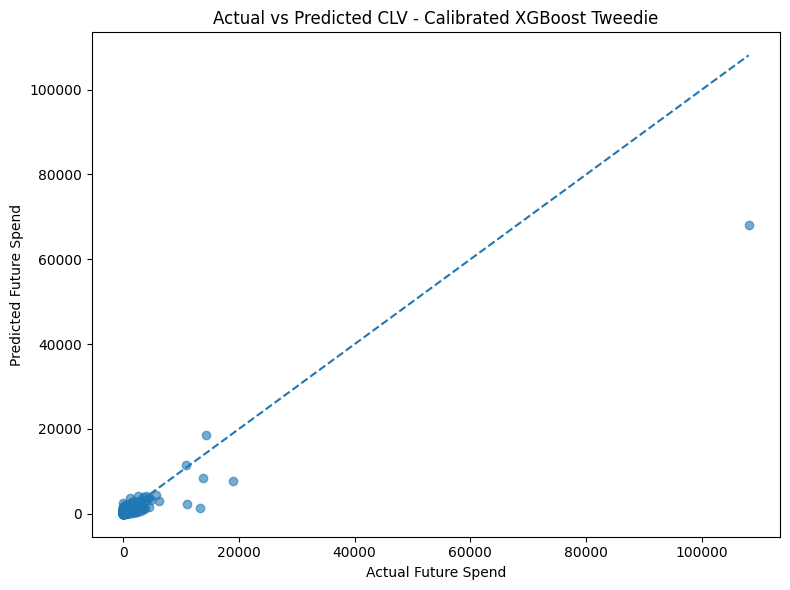

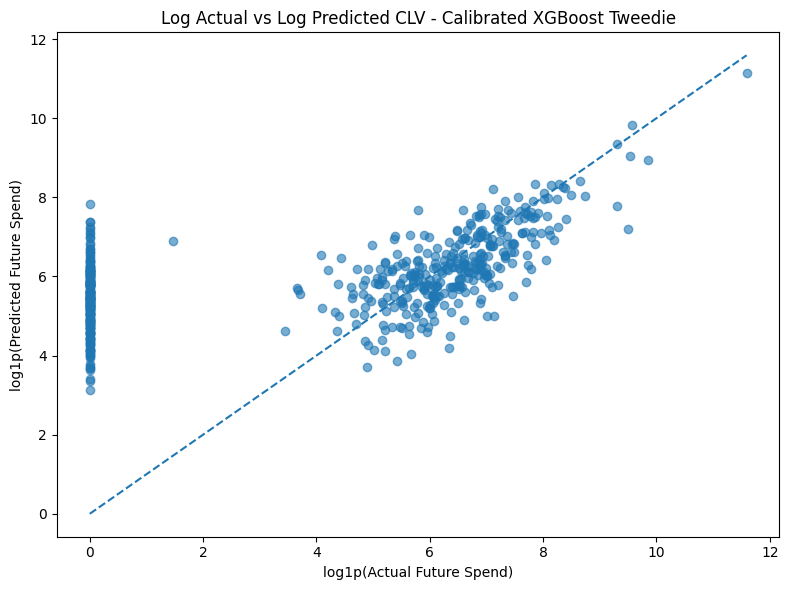

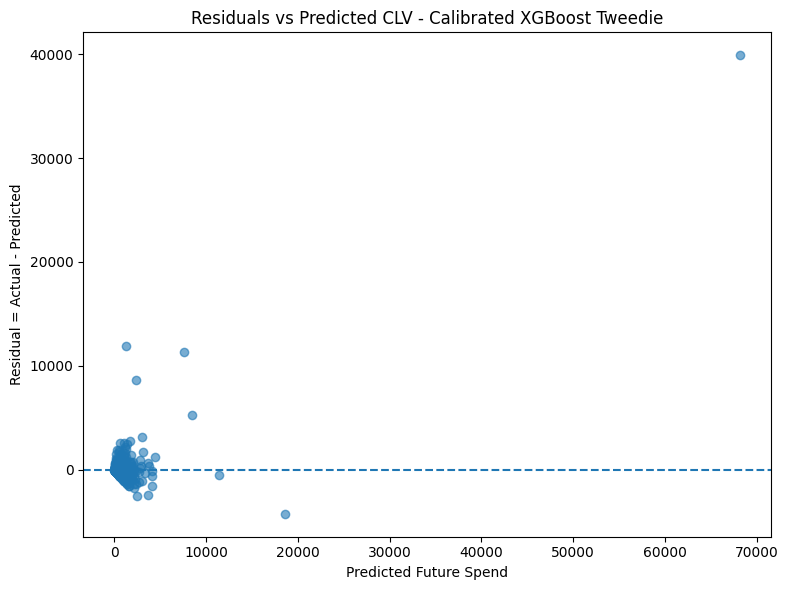

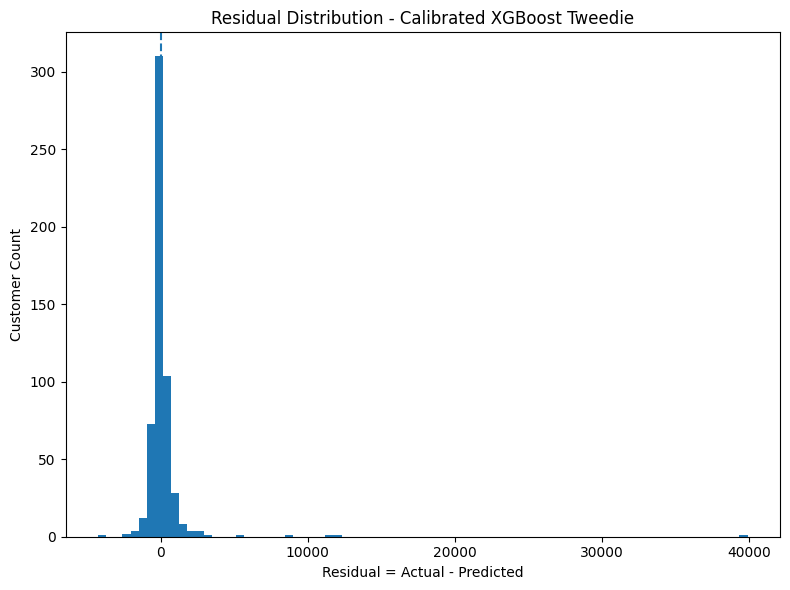

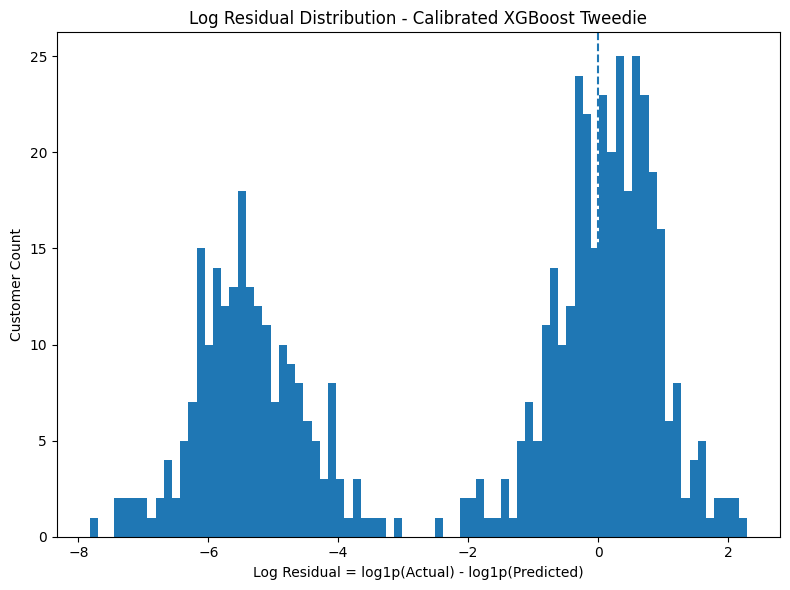


--- ERROR BY ACTUAL CLV DECILE ---
   ActualDecile  Count   MeanActual  MeanPredicted  ActualRevenue  \
0             1     56     0.000000     297.050899           0.00   
1             2     56     0.000000     353.422789           0.00   
2             3     55     0.000000     290.374381           0.00   
3             4     56     7.295536     310.537077         408.55   
4             5     55   160.704182     317.609416        8838.73   
5             6     56   313.816607     404.065489       17573.73   
6             7     55   511.649455     428.518284       28140.72   
7             8     56   815.996607     720.402581       45695.81   
8             9     55  1246.826545    1048.009255       68575.46   
9            10     56  5885.104107    3770.286225      329565.83   

   PredictedRevenue          MAE     MedianAE  RevenueError_%  
0      16634.850371   297.050899   221.471423             NaN  
1      19791.676183   353.422789   265.400831             NaN  
2      15970

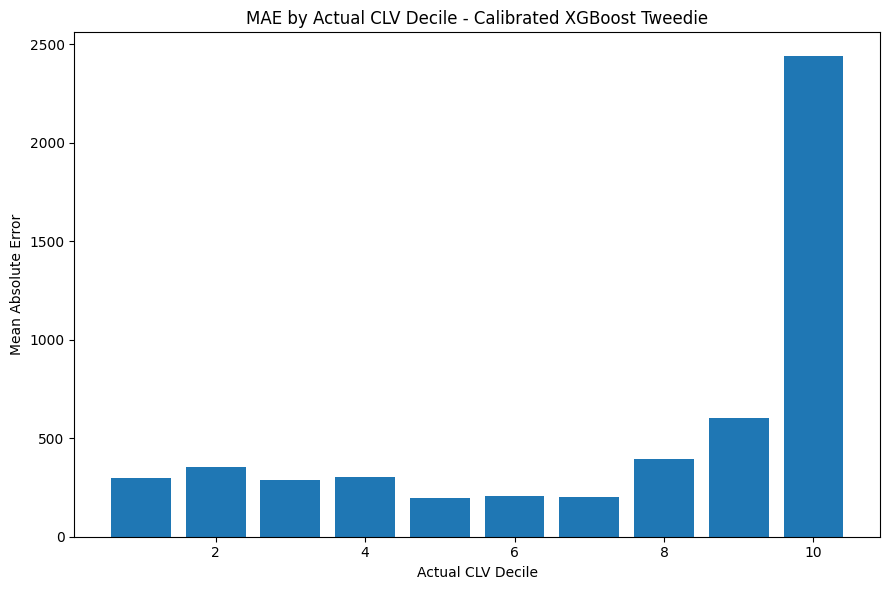

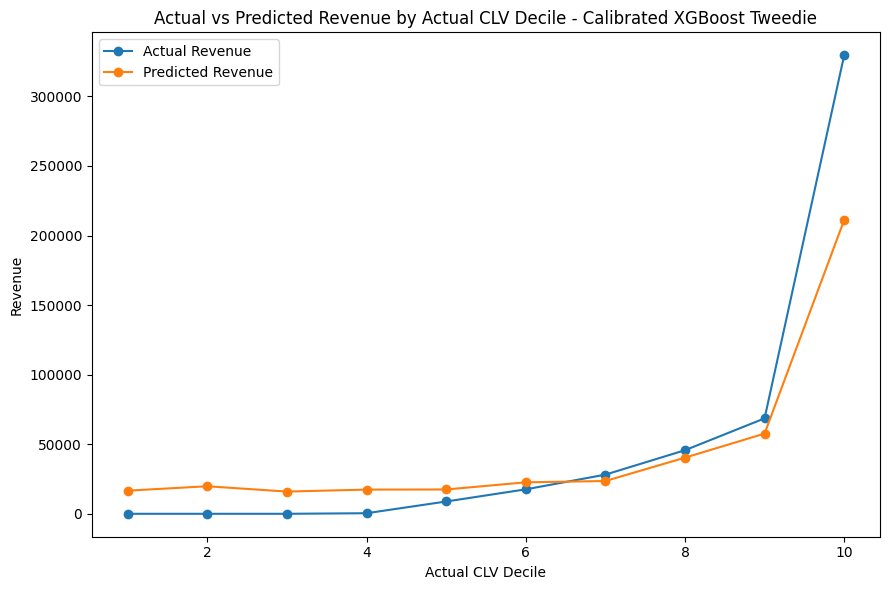


--- PREDICTED DECILE CALIBRATION ---
   PredictedDecile  Count   MeanActual  MeanPredicted  ActualRevenue  \
0                1     56    62.498571      69.652489        3499.92   
1                2     56   148.821607     134.615315        8334.01   
2                3     55   147.455091     199.127562        8110.03   
3                4     56   202.484643     259.365199       11339.14   
4                5     55   301.408727     327.068641       16577.48   
5                6     56   365.208571     411.297209       20451.68   
6                7     55   548.554909     508.050910       30170.52   
7                8     56   670.150357     688.701215       37528.42   
8                9     55  1402.200545    1126.940649       77121.03   
9               10     56  5101.189286    4216.826429      285666.60   

   PredictedRevenue  RevenueError_%  
0       3900.539397       11.446530  
1       7538.457647        9.545853  
2      10952.015914       35.042853  
3      14524.4511

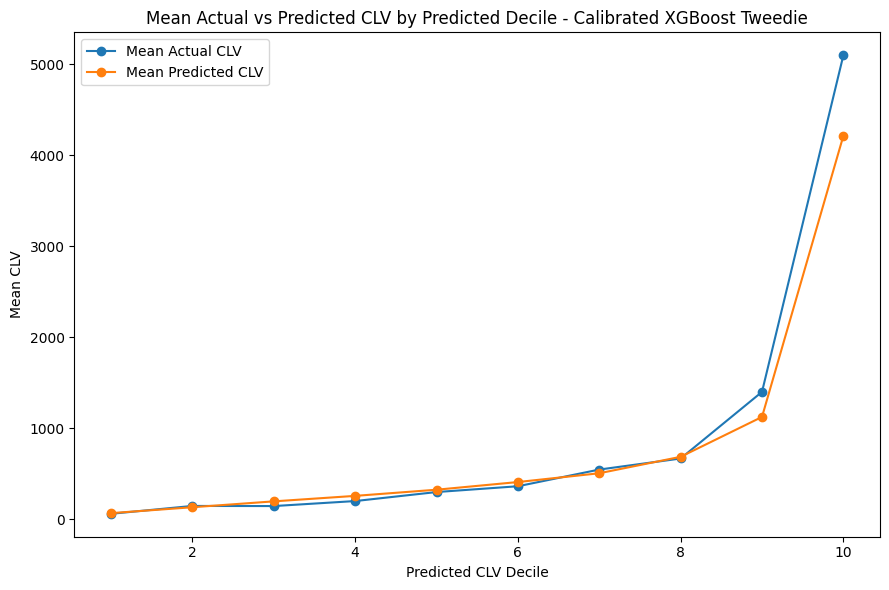

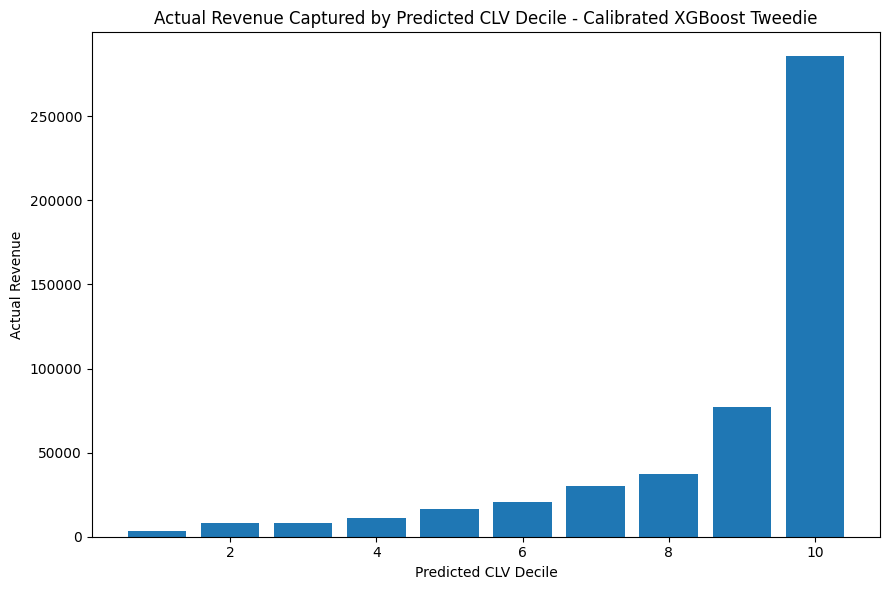


--- CLV LIFT TABLE ---
   TopCustomer_%  CustomerCount  ActualRevenueCaptured  RevenueCapture_%  \
0            5.0             27              238827.45         47.880515   
1           10.0             55              284827.57         57.102694   
2           20.0            111              362787.63         72.732254   
3           30.0            166              400071.71         80.207027   
4           50.0            278              450938.25         90.404833   

   LiftVsRandom  
0      9.576103  
1      5.710269  
2      3.636613  
3      2.673568  
4      1.808097  


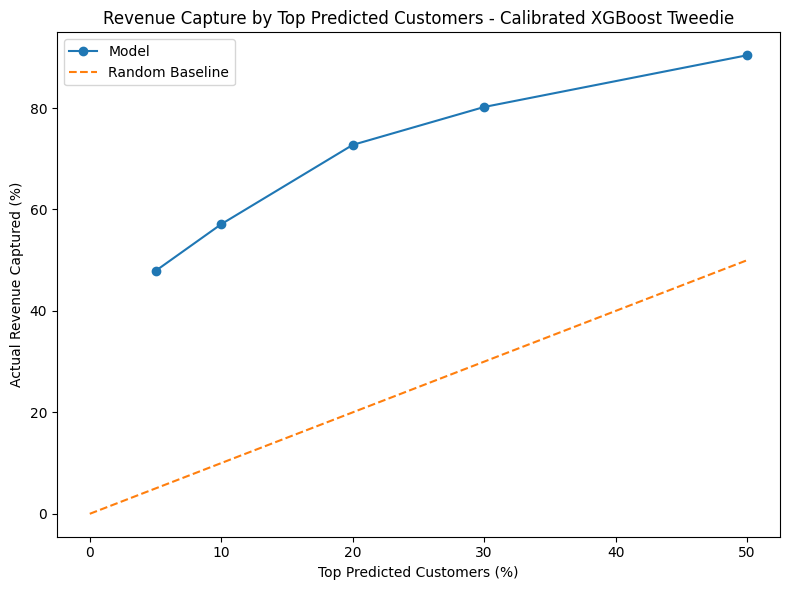

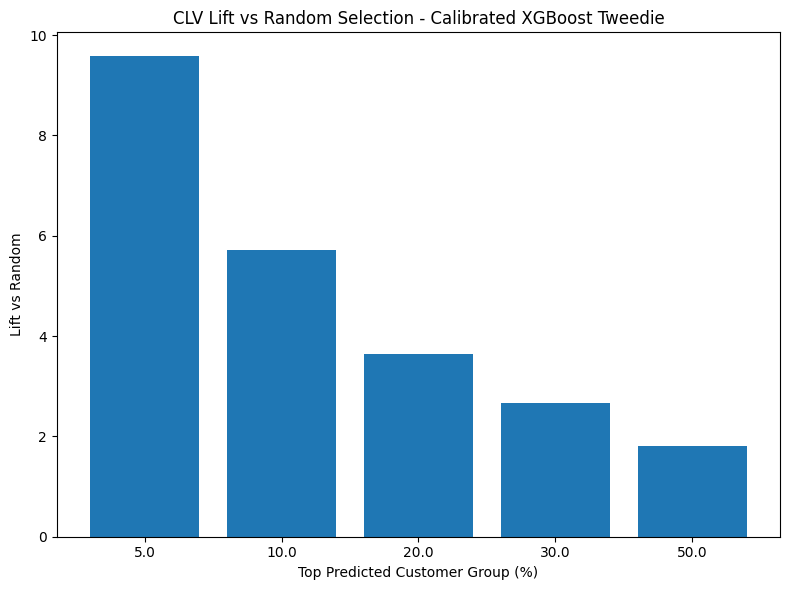


--- ZERO-SPENDER DIAGNOSTICS ---
Zero-spender count: 214
Positive-spender count: 342
Average predicted CLV for zero-spenders: 309.9263014143292
Median predicted CLV for zero-spenders: 228.19649182821496
Total predicted revenue assigned to zero-spenders: 66324.22850266645
Share of predicted revenue assigned to zero-spenders: 14.99%


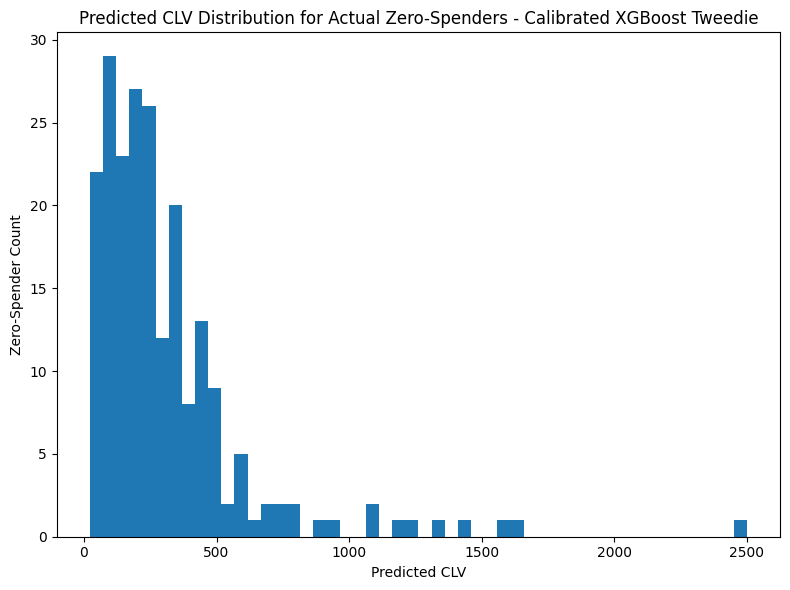


Saved CLV diagnostic tables:
clv_diagnostic_tables\clv_model_comparison.csv
clv_diagnostic_tables\clv_residual_diagnostics.csv
clv_diagnostic_tables\clv_error_by_actual_decile.csv
clv_diagnostic_tables\clv_predicted_decile_calibration.csv
clv_diagnostic_tables\clv_lift_table.csv
clv_diagnostic_tables\clv_zero_spender_diagnostics.csv

Saved CLV diagnostic plots in folder:
clv_diagnostic_plots


In [13]:
import os
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.impute import SimpleImputer

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    root_mean_squared_error,
    median_absolute_error
)

from clv_dataset import build_retention_dataset
from preprocessing import preprocess_online_retail


# HIDING LIGHTGBM FEATURE NAME WARNINGS
warnings.filterwarnings(
    "ignore",
    message="X does not have valid feature names.*"
)


# CREATING OUTPUT DIRECTORIES
PLOT_DIR = "clv_diagnostic_plots"
TABLE_DIR = "clv_diagnostic_tables"

os.makedirs(
    PLOT_DIR,
    exist_ok=True
)

os.makedirs(
    TABLE_DIR,
    exist_ok=True
)


# FUNCTION FOR REGRESSION METRICS
# FUNCTION FOR REGRESSION METRICS
def calculate_regression_metrics(y_true, y_pred):

    y_true_array = np.asarray(y_true)

    y_pred_array = np.asarray(y_pred)

    y_pred_array = np.maximum(
        0,
        y_pred_array
    )

    total_actual = y_true_array.sum()

    total_predicted = y_pred_array.sum()

    mse = mean_squared_error(
        y_true_array,
        y_pred_array
    )

    rmse = root_mean_squared_error(
        y_true_array,
        y_pred_array
    )

    mae = mean_absolute_error(
        y_true_array,
        y_pred_array
    )

    r2 = r2_score(
        y_true_array,
        y_pred_array
    )

    median_ae = median_absolute_error(
        y_true_array,
        y_pred_array
    )

    rmsle = root_mean_squared_error(
        np.log1p(y_true_array),
        np.log1p(y_pred_array)
    )

    if total_actual != 0:

        revenue_error_pct = (
            abs(total_actual - total_predicted) /
            total_actual
        ) * 100

        prediction_actual_ratio = (
            total_predicted /
            total_actual
        )

        wmape = (
            np.sum(
                np.abs(y_true_array - y_pred_array)
            ) /
            total_actual
        ) * 100

    else:

        revenue_error_pct = np.nan

        prediction_actual_ratio = np.nan

        wmape = np.nan

    # Spearman is undefined if predictions or actuals are constant
    if (
        np.std(y_true_array) == 0 or
        np.std(y_pred_array) == 0
    ):

        spearman_rank_corr = np.nan

    else:

        spearman_rank_corr = pd.Series(
            y_true_array
        ).corr(
            pd.Series(y_pred_array),
            method='spearman'
        )

    return {
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2,
        'MEDIAN_AE': median_ae,
        'RMSLE': rmsle,
        'WMAPE_%': wmape,
        'Revenue_Error_%': revenue_error_pct,
        'Prediction_Actual_Ratio': prediction_actual_ratio,
        'Spearman_Rank_Correlation': spearman_rank_corr,
        'Actual_Total_Revenue': total_actual,
        'Predicted_Total_Revenue': total_predicted
    }

# FUNCTION FOR PRINTING METRICS
def print_metrics(metrics, prefix=""):

    print(f"{prefix}MSE: {metrics['MSE']:.4f}")

    print(f"{prefix}RMSE: {metrics['RMSE']:.4f}")

    print(f"{prefix}MAE: {metrics['MAE']:.4f}")

    print(f"{prefix}R2: {metrics['R2']:.4f}")

    print(f"{prefix}MEDIAN_AE: {metrics['MEDIAN_AE']:.4f}")

    print(f"{prefix}RMSLE: {metrics['RMSLE']:.4f}")

    print(f"{prefix}WMAPE %: {metrics['WMAPE_%']:.2f}")

    print(f"{prefix}Revenue Error %: {metrics['Revenue_Error_%']:.2f}")

    print(f"{prefix}Prediction / Actual Ratio: {metrics['Prediction_Actual_Ratio']:.4f}")

    print(f"{prefix}Spearman Rank Correlation: {metrics['Spearman_Rank_Correlation']:.4f}")


# FUNCTION FOR CREATING CLV DIAGNOSTIC DATAFRAME
def create_clv_diagnostic_df(y_true, y_pred):

    y_pred = np.maximum(
        0,
        y_pred
    )

    diagnostic_df = pd.DataFrame({
        'Actual': np.array(y_true),
        'Predicted': np.array(y_pred)
    })

    diagnostic_df['Residual'] = (
        diagnostic_df['Actual'] -
        diagnostic_df['Predicted']
    )

    diagnostic_df['AbsResidual'] = (
        diagnostic_df['Residual']
        .abs()
    )

    diagnostic_df['LogActual'] = np.log1p(
        diagnostic_df['Actual']
    )

    diagnostic_df['LogPredicted'] = np.log1p(
        diagnostic_df['Predicted']
    )

    diagnostic_df['LogResidual'] = (
        diagnostic_df['LogActual'] -
        diagnostic_df['LogPredicted']
    )

    diagnostic_df['ActualZeroFlag'] = (
        diagnostic_df['Actual'] == 0
    ).astype(int)

    return diagnostic_df


# FUNCTION FOR RESIDUAL PLOTS
def plot_clv_residuals(y_true, y_pred, model_name="Calibrated XGBoost Tweedie"):

    diagnostic_df = create_clv_diagnostic_df(
        y_true,
        y_pred
    )

    print("\n--- CLV RESIDUAL SUMMARY ---")

    print(
        diagnostic_df[
            [
                'Actual',
                'Predicted',
                'Residual',
                'AbsResidual',
                'LogResidual'
            ]
        ].describe()
    )

    print("\n--- TOP 10 UNDERPREDICTED CUSTOMERS ---")

    print(
        diagnostic_df
        .sort_values(
            by='Residual',
            ascending=False
        )
        .head(10)
    )

    print("\n--- TOP 10 OVERPREDICTED CUSTOMERS ---")

    print(
        diagnostic_df
        .sort_values(
            by='Residual',
            ascending=True
        )
        .head(10)
    )

    # ACTUAL VS PREDICTED ON ORIGINAL SCALE
    plt.figure(figsize=(8, 6))

    plt.scatter(
        diagnostic_df['Actual'],
        diagnostic_df['Predicted'],
        alpha=0.6
    )

    max_value = max(
        diagnostic_df['Actual'].max(),
        diagnostic_df['Predicted'].max()
    )

    plt.plot(
        [0, max_value],
        [0, max_value],
        linestyle='--'
    )

    plt.title(
        f'Actual vs Predicted CLV - {model_name}'
    )

    plt.xlabel('Actual Future Spend')

    plt.ylabel('Predicted Future Spend')

    plt.tight_layout()

    plt.savefig(
        os.path.join(PLOT_DIR, "01_actual_vs_predicted_clv.png"),
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()

    plt.close()


    # ACTUAL VS PREDICTED ON LOG SCALE
    plt.figure(figsize=(8, 6))

    plt.scatter(
        diagnostic_df['LogActual'],
        diagnostic_df['LogPredicted'],
        alpha=0.6
    )

    max_log_value = max(
        diagnostic_df['LogActual'].max(),
        diagnostic_df['LogPredicted'].max()
    )

    plt.plot(
        [0, max_log_value],
        [0, max_log_value],
        linestyle='--'
    )

    plt.title(
        f'Log Actual vs Log Predicted CLV - {model_name}'
    )

    plt.xlabel('log1p(Actual Future Spend)')

    plt.ylabel('log1p(Predicted Future Spend)')

    plt.tight_layout()

    plt.savefig(
        os.path.join(PLOT_DIR, "02_log_actual_vs_log_predicted_clv.png"),
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()

    plt.close()


    # RESIDUALS VS PREDICTED
    plt.figure(figsize=(8, 6))

    plt.scatter(
        diagnostic_df['Predicted'],
        diagnostic_df['Residual'],
        alpha=0.6
    )

    plt.axhline(
        0,
        linestyle='--'
    )

    plt.title(
        f'Residuals vs Predicted CLV - {model_name}'
    )

    plt.xlabel('Predicted Future Spend')

    plt.ylabel('Residual = Actual - Predicted')

    plt.tight_layout()

    plt.savefig(
        os.path.join(PLOT_DIR, "03_residuals_vs_predicted_clv.png"),
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()

    plt.close()


    # RESIDUAL DISTRIBUTION
    plt.figure(figsize=(8, 6))

    plt.hist(
        diagnostic_df['Residual'],
        bins=80
    )

    plt.axvline(
        0,
        linestyle='--'
    )

    plt.title(
        f'Residual Distribution - {model_name}'
    )

    plt.xlabel('Residual = Actual - Predicted')

    plt.ylabel('Customer Count')

    plt.tight_layout()

    plt.savefig(
        os.path.join(PLOT_DIR, "04_residual_distribution.png"),
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()

    plt.close()


    # LOG RESIDUAL DISTRIBUTION
    plt.figure(figsize=(8, 6))

    plt.hist(
        diagnostic_df['LogResidual'],
        bins=80
    )

    plt.axvline(
        0,
        linestyle='--'
    )

    plt.title(
        f'Log Residual Distribution - {model_name}'
    )

    plt.xlabel('Log Residual = log1p(Actual) - log1p(Predicted)')

    plt.ylabel('Customer Count')

    plt.tight_layout()

    plt.savefig(
        os.path.join(PLOT_DIR, "05_log_residual_distribution.png"),
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()

    plt.close()

    return diagnostic_df


# FUNCTION FOR ERROR BY ACTUAL CLV DECILE
def plot_error_by_actual_decile(diagnostic_df, model_name="Calibrated XGBoost Tweedie"):

    decile_df = diagnostic_df.copy()

    decile_df['ActualDecile'] = pd.qcut(
        decile_df['Actual'].rank(method='first'),
        q=10,
        labels=False
    ) + 1

    decile_error = (
        decile_df
        .groupby('ActualDecile')
        .agg(
            Count=('Actual', 'count'),
            MeanActual=('Actual', 'mean'),
            MeanPredicted=('Predicted', 'mean'),
            ActualRevenue=('Actual', 'sum'),
            PredictedRevenue=('Predicted', 'sum'),
            MAE=('AbsResidual', 'mean'),
            MedianAE=('AbsResidual', 'median')
        )
        .reset_index()
    )

    decile_error['RevenueError_%'] = (
        abs(
            decile_error['ActualRevenue'] -
            decile_error['PredictedRevenue']
        ) /
        decile_error['ActualRevenue'].replace(0, np.nan)
    ) * 100

    print("\n--- ERROR BY ACTUAL CLV DECILE ---")

    print(decile_error)

    plt.figure(figsize=(9, 6))

    plt.bar(
        decile_error['ActualDecile'],
        decile_error['MAE']
    )

    plt.title(
        f'MAE by Actual CLV Decile - {model_name}'
    )

    plt.xlabel('Actual CLV Decile')

    plt.ylabel('Mean Absolute Error')

    plt.tight_layout()

    plt.savefig(
        os.path.join(PLOT_DIR, "06_mae_by_actual_clv_decile.png"),
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()

    plt.close()


    plt.figure(figsize=(9, 6))

    plt.plot(
        decile_error['ActualDecile'],
        decile_error['ActualRevenue'],
        marker='o',
        label='Actual Revenue'
    )

    plt.plot(
        decile_error['ActualDecile'],
        decile_error['PredictedRevenue'],
        marker='o',
        label='Predicted Revenue'
    )

    plt.title(
        f'Actual vs Predicted Revenue by Actual CLV Decile - {model_name}'
    )

    plt.xlabel('Actual CLV Decile')

    plt.ylabel('Revenue')

    plt.legend()

    plt.tight_layout()

    plt.savefig(
        os.path.join(PLOT_DIR, "07_revenue_by_actual_clv_decile.png"),
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()

    plt.close()

    return decile_error


# FUNCTION FOR PREDICTED DECILE CALIBRATION
def plot_predicted_decile_calibration(diagnostic_df, model_name="Calibrated XGBoost Tweedie"):

    calibration_df = diagnostic_df.copy()

    calibration_df['PredictedDecile'] = pd.qcut(
        calibration_df['Predicted'].rank(method='first'),
        q=10,
        labels=False
    ) + 1

    decile_calibration = (
        calibration_df
        .groupby('PredictedDecile')
        .agg(
            Count=('Actual', 'count'),
            MeanActual=('Actual', 'mean'),
            MeanPredicted=('Predicted', 'mean'),
            ActualRevenue=('Actual', 'sum'),
            PredictedRevenue=('Predicted', 'sum')
        )
        .reset_index()
    )

    decile_calibration['RevenueError_%'] = (
        abs(
            decile_calibration['ActualRevenue'] -
            decile_calibration['PredictedRevenue']
        ) /
        decile_calibration['ActualRevenue'].replace(0, np.nan)
    ) * 100

    print("\n--- PREDICTED DECILE CALIBRATION ---")

    print(decile_calibration)

    plt.figure(figsize=(9, 6))

    plt.plot(
        decile_calibration['PredictedDecile'],
        decile_calibration['MeanActual'],
        marker='o',
        label='Mean Actual CLV'
    )

    plt.plot(
        decile_calibration['PredictedDecile'],
        decile_calibration['MeanPredicted'],
        marker='o',
        label='Mean Predicted CLV'
    )

    plt.title(
        f'Mean Actual vs Predicted CLV by Predicted Decile - {model_name}'
    )

    plt.xlabel('Predicted CLV Decile')

    plt.ylabel('Mean CLV')

    plt.legend()

    plt.tight_layout()

    plt.savefig(
        os.path.join(PLOT_DIR, "08_mean_clv_by_predicted_decile.png"),
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()

    plt.close()


    plt.figure(figsize=(9, 6))

    plt.bar(
        decile_calibration['PredictedDecile'],
        decile_calibration['ActualRevenue']
    )

    plt.title(
        f'Actual Revenue Captured by Predicted CLV Decile - {model_name}'
    )

    plt.xlabel('Predicted CLV Decile')

    plt.ylabel('Actual Revenue')

    plt.tight_layout()

    plt.savefig(
        os.path.join(PLOT_DIR, "09_actual_revenue_by_predicted_decile.png"),
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()

    plt.close()

    return decile_calibration


# FUNCTION FOR CLV LIFT TABLE AND PLOT
def plot_clv_lift(diagnostic_df, model_name="Calibrated XGBoost Tweedie"):

    lift_df = diagnostic_df.copy()

    lift_df = lift_df.sort_values(
        by='Predicted',
        ascending=False
    )

    total_revenue = lift_df['Actual'].sum()

    rows = []

    for pct in [0.05, 0.10, 0.20, 0.30, 0.50]:

        customer_count = int(
            len(lift_df) * pct
        )

        top_customers = lift_df.head(
            customer_count
        )

        captured_revenue = top_customers['Actual'].sum()

        revenue_capture_pct = (
            captured_revenue /
            total_revenue
        ) * 100

        lift_vs_random = (
            revenue_capture_pct /
            (pct * 100)
        )

        rows.append({
            'TopCustomer_%': pct * 100,
            'CustomerCount': customer_count,
            'ActualRevenueCaptured': captured_revenue,
            'RevenueCapture_%': revenue_capture_pct,
            'LiftVsRandom': lift_vs_random
        })

    lift_table = pd.DataFrame(rows)

    print("\n--- CLV LIFT TABLE ---")

    print(lift_table)

    plt.figure(figsize=(8, 6))

    plt.plot(
        lift_table['TopCustomer_%'],
        lift_table['RevenueCapture_%'],
        marker='o',
        label='Model'
    )

    plt.plot(
        [0, 50],
        [0, 50],
        linestyle='--',
        label='Random Baseline'
    )

    plt.title(
        f'Revenue Capture by Top Predicted Customers - {model_name}'
    )

    plt.xlabel('Top Predicted Customers (%)')

    plt.ylabel('Actual Revenue Captured (%)')

    plt.legend()

    plt.tight_layout()

    plt.savefig(
        os.path.join(PLOT_DIR, "10_revenue_capture_by_top_customers.png"),
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()

    plt.close()


    plt.figure(figsize=(8, 6))

    plt.bar(
        lift_table['TopCustomer_%'].astype(str),
        lift_table['LiftVsRandom']
    )

    plt.title(
        f'CLV Lift vs Random Selection - {model_name}'
    )

    plt.xlabel('Top Predicted Customer Group (%)')

    plt.ylabel('Lift vs Random')

    plt.tight_layout()

    plt.savefig(
        os.path.join(PLOT_DIR, "11_clv_lift_vs_random.png"),
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()

    plt.close()

    return lift_table


# FUNCTION FOR ZERO-SPENDER DIAGNOSTICS
def plot_zero_spender_diagnostics(diagnostic_df, model_name="Calibrated XGBoost Tweedie"):

    zero_customers = diagnostic_df[
        diagnostic_df['Actual'] == 0
    ]

    positive_customers = diagnostic_df[
        diagnostic_df['Actual'] > 0
    ]

    total_predicted_revenue = diagnostic_df['Predicted'].sum()

    zero_predicted_revenue = zero_customers['Predicted'].sum()

    if total_predicted_revenue != 0:

        zero_predicted_share = (
            zero_predicted_revenue /
            total_predicted_revenue
        ) * 100

    else:

        zero_predicted_share = np.nan

    print("\n--- ZERO-SPENDER DIAGNOSTICS ---")

    print("Zero-spender count:", len(zero_customers))

    print("Positive-spender count:", len(positive_customers))

    print(
        "Average predicted CLV for zero-spenders:",
        zero_customers['Predicted'].mean()
    )

    print(
        "Median predicted CLV for zero-spenders:",
        zero_customers['Predicted'].median()
    )

    print(
        "Total predicted revenue assigned to zero-spenders:",
        zero_predicted_revenue
    )

    print(
        "Share of predicted revenue assigned to zero-spenders:",
        f"{zero_predicted_share:.2f}%"
    )

    plt.figure(figsize=(8, 6))

    plt.hist(
        zero_customers['Predicted'],
        bins=50
    )

    plt.title(
        f'Predicted CLV Distribution for Actual Zero-Spenders - {model_name}'
    )

    plt.xlabel('Predicted CLV')

    plt.ylabel('Zero-Spender Count')

    plt.tight_layout()

    plt.savefig(
        os.path.join(PLOT_DIR, "12_zero_spender_predicted_clv_distribution.png"),
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()

    plt.close()

    return zero_customers


# LOADING CLEANED MASTER DATASET
df = preprocess_online_retail(
    file_path="online_retail_II.xlsx",
    verbose=False
)

# BUILDING CUSTOMER CLV DATASET
clv_df = build_retention_dataset(
    df,
    cutoff_date='2011-09-09',
    prediction_days=90,
    active_days=180,
    verbose=True
)

# HANDLING AvgGapDays MISSING VALUES
clv_df['AvgGapDays'] = (
    clv_df['AvgGapDays']
    .fillna(999)
)

# CORRECT CLV TARGET SUMMARY
print("\nCorrect CLV Target Summary:")

print(
    "Total customers:",
    len(clv_df)
)

print(
    "Customers with future spend > 0:",
    (clv_df['FutureSpend90Days'] > 0).sum()
)

print(
    "Customers with future spend = 0:",
    (clv_df['FutureSpend90Days'] == 0).sum()
)

print(
    "Average future spend:",
    f"{clv_df['FutureSpend90Days'].mean():.2f}"
)

# SPLITTING FEATURES AND TARGET
X = clv_df.drop(
    columns=[
        'Customer_ID',
        'FutureSpend90Days'
    ],
    errors='ignore'
)

# TARGET LABELS WITHOUT LOG TRANSFORM FOR TWEEDIE
y = clv_df['FutureSpend90Days']

# CREATING CLASSIFICATION LABEL ONLY FOR STRATIFICATION
y_class = (
    y > 0
).astype(int)

# TRAIN TEST SPLIT
X_train, X_test, y_train, y_test, y_class_train, y_class_test = train_test_split(
    X,
    y,
    y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)

# FEATURES NEEDING LOG TRANSFORMATION
log_features = [
    'Frequency',
    'Monetary',
    'AvgBasketValue',
    'UniqueProducts',
    'SpendLast30Days',
    'SpendLast90Days',
    'SpendPrior90Days',
    'RevenuePerDay',
    'AvgSpendPerProduct',
    'ProductDiversityRate'
]

# FEATURES NEEDING NORMAL SCALING ONLY
scale_features = [
    'AvgQuantity',
    'Recency',
    'LifetimeDays',
    'PurchaseRate',
    'AvgGapDays',
    'StdGapDays',
    'PurchasesLast30Days',
    'PurchasesLast90Days',
    'ReturnRate',
    'IsNewCustomer',
    'RecencyFrequency',
    'SpendTrendRatio',
    'FrequencyLast90DaysRatio'
]

# PIPELINE FOR LOG-TRANSFORMED FEATURES
log_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('log_transform', FunctionTransformer(np.log1p)),
    ('scaler', StandardScaler())
])

# PIPELINE FOR STANDARD-SCALED FEATURES
scale_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# COMBINING PREPROCESSING PIPELINES
preprocessor = ColumnTransformer([
    ('log', log_pipeline, log_features),
    ('scale', scale_pipeline, scale_features)
],
    remainder='drop'
)

# DEFINING MODELS WITH TWEEDIE OBJECTIVE
models = {
    'XGBoost_Tweedie': XGBRegressor(
        objective='reg:tweedie',
        eval_metric='tweedie-nloglik@1.5',
        tweedie_variance_power=1.5,
        tree_method='hist',
        random_state=42,
        n_jobs=1
    ),
    'LGBM_Tweedie': LGBMRegressor(
        objective='tweedie',
        tweedie_variance_power=1.5,
        random_state=42,
        verbose=-1
    )
}

# DEFINING RANDOM SEARCH PARAMETER GRIDS
param_grids = {
    'XGBoost_Tweedie': {
        'model__n_estimators': [100, 200, 500, 1000],
        'model__max_depth': [2, 3, 4, 5],
        'model__learning_rate': [0.01, 0.03, 0.05, 0.1],
        'model__subsample': [0.6, 0.8, 1.0],
        'model__colsample_bytree': [0.6, 0.8, 1.0],
        'model__min_child_weight': [1, 3, 5, 7],
        'model__reg_alpha': [0, 0.01, 0.1],
        'model__reg_lambda': [1, 2, 5, 10],
        'model__tweedie_variance_power': [1.1, 1.3, 1.5, 1.7, 1.9]
    },
    'LGBM_Tweedie': {
        'model__n_estimators': [100, 200, 500, 1000],
        'model__learning_rate': [0.01, 0.03, 0.05, 0.1],
        'model__max_depth': [3, 5, 7, -1],
        'model__num_leaves': [15, 31, 63],
        'model__subsample': [0.6, 0.8, 1.0],
        'model__colsample_bytree': [0.6, 0.8, 1.0],
        'model__min_child_samples': [10, 20, 50],
        'model__reg_alpha': [0, 0.01, 0.1, 1],
        'model__reg_lambda': [0.1, 1, 5, 10],
        'model__tweedie_variance_power': [1.1, 1.3, 1.5, 1.7, 1.9]
    }
}

# BASELINE MODEL
baseline_pred = np.repeat(
    y_train.mean(),
    len(y_test)
)

baseline_metrics = calculate_regression_metrics(
    y_test,
    baseline_pred
)

print("\n--- BASELINE MODEL ---")

print_metrics(
    baseline_metrics,
    prefix="Baseline "
)


# STORING MODEL RESULTS
results = []
trained_models = {}
final_model_predictions = {}

# ADDING BASELINE TO RESULTS
baseline_result = baseline_metrics.copy()

baseline_result['Model'] = 'Baseline_Mean'

baseline_result['Version'] = 'Baseline'

baseline_result['Calibration_Factor'] = 1.0

results.append(
    baseline_result
)


# TRAINING AND EVALUATING MODELS
for model_name, model in models.items():

    print(f"\nTraining {model_name}...")

    pipeline = Pipeline([
        ('preprocessing', preprocessor),
        ('model', model)
    ])

    random_search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_grids[model_name],
        n_iter=100,
        cv=5,
        scoring='neg_root_mean_squared_error',
        random_state=42,
        n_jobs=-1
    )

    random_search.fit(
        X_train,
        y_train
    )

    best_model = random_search.best_estimator_

    trained_models[model_name] = best_model

    # PREDICTING RAW FUTURE SPEND
    y_train_pred = best_model.predict(
        X_train
    )

    y_pred = best_model.predict(
        X_test
    )

    # CLIPPING NEGATIVE PREDICTIONS
    y_train_pred = np.maximum(
        0,
        y_train_pred
    )

    y_pred = np.maximum(
        0,
        y_pred
    )

    # CALIBRATION FACTOR USING TRAINING DATA ONLY
    if y_train_pred.sum() != 0:

        calibration_factor = (
            y_train.sum() /
            y_train_pred.sum()
        )

    else:

        calibration_factor = 1.0

    # CALIBRATED TEST PREDICTIONS
    y_pred_calibrated = (
        y_pred *
        calibration_factor
    )

    y_pred_calibrated = np.maximum(
        0,
        y_pred_calibrated
    )

    # UNCALIBRATED METRICS
    uncalibrated_metrics = calculate_regression_metrics(
        y_test,
        y_pred
    )

    # CALIBRATED METRICS
    calibrated_metrics = calculate_regression_metrics(
        y_test,
        y_pred_calibrated
    )

    print(f"Best Params: {random_search.best_params_}")

    print("\nUncalibrated:")

    print_metrics(
        uncalibrated_metrics
    )

    print("\nCalibrated:")

    print(f"Calibration Factor: {calibration_factor:.4f}")

    print_metrics(
        calibrated_metrics
    )

    print("\nRevenue Totals:")

    print(f"Actual test revenue: {y_test.sum():.2f}")

    print(f"Predicted test revenue: {y_pred.sum():.2f}")

    print(f"Calibrated predicted test revenue: {y_pred_calibrated.sum():.2f}")

    print(f"Prediction / Actual ratio: {y_pred.sum() / y_test.sum():.4f}")

    print(f"Calibrated Prediction / Actual ratio: {y_pred_calibrated.sum() / y_test.sum():.4f}")

    # STORING XGBOOST TWEEDIE PREDICTIONS FOR FINAL DIAGNOSTIC PLOTS
    if model_name == 'XGBoost_Tweedie':

        final_model_predictions['model_name'] = model_name

        final_model_predictions['y_test'] = y_test.copy()

        final_model_predictions['y_pred_uncalibrated'] = y_pred.copy()

        final_model_predictions['y_pred_calibrated'] = y_pred_calibrated.copy()

        final_model_predictions['best_model'] = best_model

        final_model_predictions['best_params'] = random_search.best_params_

        final_model_predictions['calibration_factor'] = calibration_factor

    # APPENDING UNCALIBRATED RESULTS
    uncalibrated_result = uncalibrated_metrics.copy()

    uncalibrated_result['Model'] = model_name

    uncalibrated_result['Version'] = 'Uncalibrated'

    uncalibrated_result['Calibration_Factor'] = 1.0

    results.append(
        uncalibrated_result
    )

    # APPENDING CALIBRATED RESULTS
    calibrated_result = calibrated_metrics.copy()

    calibrated_result['Model'] = model_name

    calibrated_result['Version'] = 'Calibrated'

    calibrated_result['Calibration_Factor'] = calibration_factor

    results.append(
        calibrated_result
    )


# FINAL MODEL COMPARISON TABLE
results_df = pd.DataFrame(
    results
)

results_df = results_df[
    [
        'Model',
        'Version',
        'MSE',
        'RMSE',
        'MAE',
        'R2',
        'MEDIAN_AE',
        'RMSLE',
        'WMAPE_%',
        'Revenue_Error_%',
        'Prediction_Actual_Ratio',
        'Spearman_Rank_Correlation',
        'Actual_Total_Revenue',
        'Predicted_Total_Revenue',
        'Calibration_Factor'
    ]
]

results_df = results_df.sort_values(
    by='RMSE',
    ascending=True
)

print("\nFinal Model Comparison:\n")

print(results_df)

results_df.to_csv(
    os.path.join(TABLE_DIR, "clv_model_comparison.csv"),
    index=False
)


# CHECKING FINAL MODEL STORAGE
if len(final_model_predictions) == 0:

    raise ValueError(
        "XGBoost_Tweedie predictions were not stored. Check model_name inside models dictionary."
    )


# RUNNING ALL FINAL CLV DIAGNOSTIC PLOTS FOR XGBOOST TWEEDIE
print("\n--- RUNNING FINAL CLV DIAGNOSTIC PLOTS ---")

print("\n--- FINAL MODEL USED FOR PLOTS ---")

print("Model:", final_model_predictions['model_name'])

print("Best Params:", final_model_predictions['best_params'])

print("Calibration Factor:", final_model_predictions['calibration_factor'])


final_y_test = final_model_predictions['y_test']

final_y_pred = final_model_predictions['y_pred_calibrated']

diagnostic_df = plot_clv_residuals(
    final_y_test,
    final_y_pred,
    model_name="Calibrated XGBoost Tweedie"
)

decile_error = plot_error_by_actual_decile(
    diagnostic_df,
    model_name="Calibrated XGBoost Tweedie"
)

decile_calibration = plot_predicted_decile_calibration(
    diagnostic_df,
    model_name="Calibrated XGBoost Tweedie"
)

lift_table = plot_clv_lift(
    diagnostic_df,
    model_name="Calibrated XGBoost Tweedie"
)

zero_customers = plot_zero_spender_diagnostics(
    diagnostic_df,
    model_name="Calibrated XGBoost Tweedie"
)


# SAVING DIAGNOSTIC TABLES FOR FRONTEND
diagnostic_df.to_csv(
    os.path.join(TABLE_DIR, "clv_residual_diagnostics.csv"),
    index=False
)

decile_error.to_csv(
    os.path.join(TABLE_DIR, "clv_error_by_actual_decile.csv"),
    index=False
)

decile_calibration.to_csv(
    os.path.join(TABLE_DIR, "clv_predicted_decile_calibration.csv"),
    index=False
)

lift_table.to_csv(
    os.path.join(TABLE_DIR, "clv_lift_table.csv"),
    index=False
)

zero_customers.to_csv(
    os.path.join(TABLE_DIR, "clv_zero_spender_diagnostics.csv"),
    index=False
)

print("\nSaved CLV diagnostic tables:")

print(os.path.join(TABLE_DIR, "clv_model_comparison.csv"))

print(os.path.join(TABLE_DIR, "clv_residual_diagnostics.csv"))

print(os.path.join(TABLE_DIR, "clv_error_by_actual_decile.csv"))

print(os.path.join(TABLE_DIR, "clv_predicted_decile_calibration.csv"))

print(os.path.join(TABLE_DIR, "clv_lift_table.csv"))

print(os.path.join(TABLE_DIR, "clv_zero_spender_diagnostics.csv"))

print("\nSaved CLV diagnostic plots in folder:")

print(PLOT_DIR)

The calibrated XGBoost Tweedie model achieved strong individual-level CLV prediction, reducing RMSE by about 59% over the mean baseline and achieving R2 = 0.8330. Residual diagnostics showed that most remaining error comes from underpredicting extreme high-value customers and assigning moderate predicted CLV to some actual zero-spenders. Despite this, the model ranked customers effectively: the top 10% predicted customers captured 57.1% of actual future revenue, demonstrating strong business value for customer targeting.